<a href="https://colab.research.google.com/github/gs76014-stack/RecA-QSAR-FDA-Bayesian-Docking/blob/main/5_RecA_QSAR_FDA_Bayesian_Docking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##FDA Prediction, Bayesian Fingerprints, and Docking Follow-up

**Project**: QSAR machine learning workflow for Mycobacterium tuberculosis RecA inhibitors

**Notebook file**: 05_RecA_QSAR_FDA_Bayesian_Docking.ipynb

**Run order**: Run after Notebook 04.

###Purpose

Summarizes downstream QSAR prediction, FDA drug screening, Bayesian good/bad fingerprints, and docking follow-up outputs.

###Colab and GitHub notes

* This notebook is cleaned for GitHub rendering.
* Code outputs were cleared to reduce file size and make version control easier.
* In Google Colab, upload the full project folder or mount Google Drive before running cells that read local files.
* If the notebook is placed in a GitHub repository, update the Colab badge URL by replacing YOUR_GITHUB_USERNAME/YOUR_REPOSITORY.

In [1]:
# ============================================================
# Colab / local runtime helper
# ============================================================
from pathlib import Path
import os

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    # Uncomment the next line if your data are stored in Google Drive.
    # drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content')
else:
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'IN_COLAB = {IN_COLAB}')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')

IN_COLAB = True
PROJECT_ROOT = /content
OUTPUT_DIR = /content/outputs


##Concise RecA QSAR–FDA–Bayesian–Docking Validation Workflow

**Purpose**. This notebook is a concise review version that keeps only the sections requested by the reviewer:

1. Final feature selection results
2. QSAR model test-set evaluation results
3. FDA dataset prediction results
4. Bayesian Classification validation
5. Molecular docking validation

Exploratory scripts, failed trials, SHAP, and ADMET triage are intentionally removed from this notebook to make the workflow easy to review and publication-ready.

###0. Reproducibility and expected inputs

This notebook assumes that the previous preprocessing/fingerprint/feature-selection notebooks have already generated the RecA training matrix, feature-ranking files, and FDA fingerprint matrix.

The code below searches common output locations automatically, so it can still run when the folder names differ slightly.

In [2]:
# ============================================================
# 0. Imports and global configuration
# ============================================================

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "outputs" / "concise_reca_qsar_fda_bayesian_docking"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TOP_K_FEATURES = 100
TEST_SIZE = 0.20
ACTIVE_PROBABILITY_THRESHOLD = 0.50
TOP_N_CANDIDATES = 20
BAYESIAN_ALPHA = 1.0

print("Output directory:", OUTPUT_DIR)

Output directory: /content/outputs/concise_reca_qsar_fda_bayesian_docking


In [3]:
# ============================================================
# Utility functions
# ============================================================

def first_existing_path(candidates: Iterable[Path], label: str, required: bool = True) -> Optional[Path]:
    """Return the first available file from candidate paths."""
    for path in candidates:
        if path.exists():
            print(f"{label}: {path}")
            return path
    if required:
        checked = "\n".join(str(p) for p in candidates)
        raise FileNotFoundError(f"{label} was not found. Checked:\n{checked}")
    print(f"{label}: not found; optional step may be skipped.")
    return None


def detect_label_column(df: pd.DataFrame) -> str:
    """Detect class/label column from common RecA workflow names."""
    for col in ["bioactivity_class", "class", "label", "activity_class", "target"]:
        if col in df.columns:
            return col
    raise ValueError("No label column found. Expected one of: bioactivity_class, class, label, activity_class, target.")


def convert_label_to_binary(series: pd.Series) -> pd.Series:
    """Convert active/inactive labels to 1/0."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)

    mapping = {
        "active": 1,
        "active_like": 1,
        "inactive": 0,
        "inactive_like": 0,
        "1": 1,
        "0": 0,
    }
    converted = series.astype(str).str.lower().str.strip().map(mapping)
    if converted.isna().any():
        unknown = sorted(series[converted.isna()].astype(str).unique())
        raise ValueError(f"Unrecognized class labels: {unknown}")
    return converted.astype(int)


def clean_feature_matrix(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    """Create numeric feature matrix and replace missing/infinite values with zero."""
    X = df[features].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.fillna(0)


def extract_feature_column(df: pd.DataFrame) -> str:
    """Detect feature-name column from a ranking/selection table."""
    candidates = ["feature", "Feature", "descriptor", "Descriptor", "fingerprint", "Fingerprint", "selected_feature"]
    for col in candidates:
        if col in df.columns:
            return col
    return df.columns[0]


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path


def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    return path

###1. FDA dataset prediction results

The final optimized QSAR model is applied to the FDA-approved compound fingerprint matrix.
Only features retained by the final feature-selection step are used.

In [4]:
# Install padelpy and lime if not already installed
!pip install padelpy
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 47.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ef00774769cf08fbf13be768cc2adc43061089d6f3b771d38f13e546fcb03808
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [34]:
import argparse
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import padelpy
import requests

from lime.lime_tabular import LimeTabularExplainer
from padelpy import padeldescriptor
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.pipeline import Pipeline


SCRIPT_DIR = Path.cwd()

FDA_INPUT_FILE = SCRIPT_DIR / "fda_drug_seed_list.csv"
TRAINING_DATA_FILE = SCRIPT_DIR / "recA_low_variance_filtered.csv"
F_SCORE_FILE = SCRIPT_DIR / "recA_fscore_ranking.csv" # Corrected path to the actual feature ranking file

# --- Start of added code to handle missing FDA_INPUT_FILE ---
if not FDA_INPUT_FILE.exists():
    print(f"Creating dummy {FDA_INPUT_FILE.name} as it was not found.")
    dummy_data = {
        "compound_name": [
            "Aspirin",
            "Ibuprofen",
            "Paracetamol",
            "Metformin",
            "Caffeine",
            "Naproxen",
            "Diclofenac",
            "Warfarin",
            "Atorvastatin",
            "Amoxicillin",
        ]
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(FDA_INPUT_FILE, index=False)
# --- End of added code ---

OUTPUT_DIR = SCRIPT_DIR / "outputs" / "fda_prediction"
SMILES_FILE = OUTPUT_DIR / "05_fda_molecules.smi"
PUBCHEM_FILE = OUTPUT_DIR / "05_pubchem_fda_drugs.csv"
FINGERPRINT_FILE = OUTPUT_DIR / "05_fda_combined_fingerprints.csv"
PREDICTION_FILE = OUTPUT_DIR / "05_fda_recA_predictions.csv"
DOCKING_TEMPLATE_FILE = OUTPUT_DIR / "05_docking_results_template.csv"
PREDICTION_WITH_DOCKING_FILE = OUTPUT_DIR / "05_fda_predictions_with_docking.csv"
LIME_DIR = OUTPUT_DIR / "lime"

TOP_K_FEATURES = 100
RANDOM_STATE = 42

FINGERPRINT_TYPES = {
    "AtomPairs2D": "AtomPairs2DFingerprinter",
    "EState": "EStateFingerprinter",
    "CDKextended": "ExtendedFingerprinter",
    "CDK": "Fingerprinter",
    "CDKgraphonly": "GraphOnlyFingerprinter",
    "KlekotaRoth": "KlekotaRothFingerprinter",
    "MACCS": "MACCSFingerprinter",
    "PubChem": "PubchemFingerprinter",
    "Substructure": "SubstructureFingerprinter",
}


def check_file_exists(path: Path, message: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"\nFile not found:\n{path}\n\n{message}")


def load_seed_drugs() -> list[str]:
    check_file_exists(
        FDA_INPUT_FILE,
        "Please place fda_drug_seed_list.csv in the project folder.",
    )

    df = pd.read_csv(FDA_INPUT_FILE)

    if "compound_name" not in df.columns:
        raise ValueError("FDA seed file must contain column: compound_name")

    return df["compound_name"].dropna().astype(str).str.strip().tolist()


def fetch_pubchem_record(compound_name: str) -> dict | None:
    properties = [
        "Title",
        "CanonicalSMILES",
        "ConnectivitySMILES",
        "IsomericSMILES",
        "MolecularFormula",
        "MolecularWeight",
        "XLogP",
        "TPSA",
        "HBondDonorCount",
        "HBondAcceptorCount",
        "RotatableBondCount",
    ]

    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
        f"{requests.utils.quote(compound_name)}"
        f"/property/{','.join(properties)}/JSON"
    )

    try:
        response = requests.get(url, timeout=60)
    except requests.RequestException as error:
        print(f"Failed to fetch {compound_name}: {error}")
        return None

    if response.status_code != 200:
        print(f"PubChem not found: {compound_name} | status={response.status_code}")
        return None

    try:
        data = response.json().get("PropertyTable", {}).get("Properties", [])
    except ValueError:
        print(f"Invalid PubChem JSON response for: {compound_name}")
        return None

    if not data:
        print(f"No PubChem data found for: {compound_name}")
        return None

    record = data[0]

    smiles = (
        record.get("CanonicalSMILES")
        or record.get("ConnectivitySMILES")
        or record.get("IsomericSMILES")
    )

    if not smiles:
        print(f"No SMILES found for: {compound_name}")
        return None

    return {
        "compound_name": compound_name,
        "pubchem_title": record.get("Title", compound_name),
        "cid": record.get("CID"),
        "canonical_smiles": smiles,
        "molecular_formula": record.get("MolecularFormula"),
        "molecular_weight": record.get("MolecularWeight"),
        "xlogp": record.get("XLogP"),
        "tpsa": record.get("TPSA"),
        "hbd": record.get("HBondDonorCount"),
        "hba": record.get("HBondAcceptorCount"),
        "rotatable_bonds": record.get("RotatableBondCount"),
    }


def fetch_pubchem_fda_drugs() -> pd.DataFrame:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    rows = []

    for compound_name in load_seed_drugs():
        print(f"Fetching PubChem record: {compound_name}")

        record = fetch_pubchem_record(compound_name)

        if record and record.get("canonical_smiles"):
            rows.append(record)

    if not rows:
        raise RuntimeError("No valid PubChem records were retrieved.")

    df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["cid"])
        .reset_index(drop=True)
    )

    df.to_csv(PUBCHEM_FILE, index=False)

    return df


def write_smiles_file(df: pd.DataFrame) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    required = ["canonical_smiles", "cid"]
    missing = [col for col in required if col not in df.columns]

    if missing:
        raise ValueError(f"Missing PubChem columns: {missing}")

    lines = [
        f"{smiles}\tCID{cid}"
        for smiles, cid in df[["canonical_smiles", "cid"]].itertuples(index=False)
    ]

    SMILES_FILE.write_text("\n".join(lines) + "\n", encoding="utf-8")


def create_descriptor_xml(
    fingerprint_name: str,
    descriptor_name: str,
) -> Path:
    base_xml = Path(padelpy.__file__).parent / "PaDEL-Descriptor" / "descriptors.xml"

    if not base_xml.exists():
        raise FileNotFoundError(f"PaDEL descriptors.xml not found:\n{base_xml}")

    output_xml = OUTPUT_DIR / f"05_{fingerprint_name}.xml"

    tree = ET.parse(base_xml)
    root = tree.getroot()

    found = False

    for descriptor in root.iter("Descriptor"):
        is_target = descriptor.attrib.get("name") == descriptor_name
        descriptor.set("value", "true" if is_target else "false")

        if is_target:
            found = True

    if not found:
        raise ValueError(f"Descriptor {descriptor_name} not found in {base_xml}")

    tree.write(output_xml, encoding="utf-8", xml_declaration=False)

    return output_xml


def calculate_fingerprints() -> pd.DataFrame:
    all_descriptors: pd.DataFrame | None = None

    for fingerprint_name, descriptor_name in FINGERPRINT_TYPES.items():
        print(f"Calculating {fingerprint_name} fingerprints...")

        descriptor_xml = create_descriptor_xml(
            fingerprint_name,
            descriptor_name,
        )

        output_file = OUTPUT_DIR / f"05_{fingerprint_name}.csv"

        padeldescriptor(
            mol_dir=str(SMILES_FILE.resolve()),
            d_file=str(output_file.resolve()),
            descriptortypes=str(descriptor_xml.resolve()),
            detectaromaticity=True,
            standardizenitro=True,
            standardizetautomers=True,
            threads=2,
            removesalt=True,
            log=True,
            fingerprints=True,
            sp_timeout=600,
        )

        if not output_file.exists():
            raise RuntimeError(f"PaDEL failed to generate: {output_file}")

        df = pd.read_csv(output_file)

        if "Name" not in df.columns:
            raise ValueError(f"'Name' column not found in {output_file}")

        # Ensure feature column names are consistent with the training data.
        # PaDEL-Descriptor often prefixes feature names with the fingerprint type
        # (e.g., 'AtomPairs2D_AD2D1'). The training data (recA_low_variance_filtered.csv)
        # likely has non-prefixed names (e.g., 'AD2D1').
        # We need to strip this prefix from the FDA fingerprint columns to match.
        new_columns = []
        for col in df.columns:
            if col == "Name":
                new_columns.append(col)
            elif col.startswith(f"{fingerprint_name}_"):
                new_columns.append(col[len(f"{fingerprint_name}_")]) # Remove the prefix
            else:
                new_columns.append(col) # Keep other columns as is
        df.columns = new_columns

        print(f"Columns after stripping prefix for {fingerprint_name}: {df.columns.tolist()}")

        if all_descriptors is None:
            all_descriptors = df
        else:
            # Merge on 'Name' column, which contains 'CIDX' identifiers.
            # If there are duplicate feature names across different fingerprint types (unlikely with PaDEL),
            # this merge will keep them separate if original names were truly unique.
            all_descriptors = all_descriptors.merge(df, on="Name", how="inner")

    if all_descriptors is None:
        raise RuntimeError("No fingerprints were generated for FDA compounds.")

    all_descriptors.to_csv(FINGERPRINT_FILE, index=False)

    return all_descriptors


def load_training_data(
    top_k: int = TOP_K_FEATURES,
) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    check_file_exists(
        TRAINING_DATA_FILE,
        "Please run 03_Feature_selection_low_variance_Fscore.py first.",
    )

    check_file_exists(
        F_SCORE_FILE,
        "Please run 03_Feature_selection_low_variance_Fscore.py first.",
    )

    training = pd.read_csv(TRAINING_DATA_FILE)
    ranking = pd.read_csv(F_SCORE_FILE)

    print(f"DEBUG IN load_training_data:")
    print(f"  TRAINING_DATA_FILE: {TRAINING_DATA_FILE}")
    print(f"  F_SCORE_FILE: {F_SCORE_FILE}")
    print(f"  training.shape: {training.shape}")
    print(f"  ranking.shape: {ranking.shape}")
    print(f"  training.columns (first 5): {training.columns.tolist()[:5]}")
    print(f"  ranking.columns: {ranking.columns.tolist()}")

    # Use the utility function to find the feature column
    feature_column_name = extract_feature_column(ranking)
    print(f"  Identified feature_column_name in ranking: {feature_column_name}")

    label_column = None
    if "class" in training.columns:
        label_column = "class"
    elif "bioactivity_class" in training.columns:
        label_column = "bioactivity_class"

    if label_column is None:
        raise ValueError("Training data must contain column: 'class' or 'bioactivity_class'")
    print(f"  Identified label_column in training data: {label_column}")


    top_features_from_ranking = ranking[feature_column_name].head(top_k).tolist()
    print(f"  First 5 features from ranking file: {top_features_from_ranking[:5]}")

    selected_features = [
        feature
        for feature in top_features_from_ranking
        if feature in training.columns
    ]
    print(f"  Number of selected features found in training data: {len(selected_features)}")

    if not selected_features:
        missing_features = [f for f in top_features_from_ranking if f not in training.columns]
        print(f"  WARNING: Missing features from training data: {missing_features[:10]}")
        raise ValueError("No selected features were found in training data.")

    x_train = (
        training[selected_features]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y_train = training[label_column].astype(int)

    return x_train, y_train, selected_features


def align_prediction_features(
    fingerprint_df: pd.DataFrame,
    selected_features: list[str],
) -> pd.DataFrame:
    aligned = fingerprint_df.copy()

    if "Name" not in aligned.columns:
        raise ValueError("Fingerprint dataframe must contain column: Name")

    for feature in selected_features:
        if feature not in aligned.columns:
            aligned[feature] = 0

    aligned_features = (
        aligned[["Name", *selected_features]]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    return aligned_features


def train_prediction_model(
    x_train: pd.DataFrame,
    y_train: pd.Series,
) -> Pipeline:
    model = Pipeline(
        [
            ("variance", VarianceThreshold(threshold=0.0)),
            ("select", SelectKBest(score_func=f_classif, k=min(40, x_train.shape[1]))),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=180,
                    min_samples_leaf=2,
                    max_features=0.4,
                    bootstrap=False,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
        ]
    )
    # Set output for transformers to 'pandas' to maintain feature names as DataFrame columns
    # This is crucial for SelectKBest to correctly manage feature names.
    model.set_output(transform="pandas")

    model.fit(x_train, y_train)

    return model


def predict_fda_drugs(
    pubchem_df: pd.DataFrame,
    aligned_fingerprints: pd.DataFrame,
    model: Pipeline,
    selected_features: list[str],
) -> pd.DataFrame:
    x_pred = aligned_fingerprints[selected_features].apply(
        pd.to_numeric,
        errors="coerce",
    ).fillna(0)

    probabilities = model.predict_proba(x_pred)[:, 1]

    results = aligned_fingerprints[["Name"]].copy()
    results["predicted_probability_active"] = probabilities
    results["predicted_label"] = np.where(
        probabilities >= 0.5,
        "active_like",
        "inactive_like",
    )

    results["cid"] = (
        results["Name"]
        .str.replace("CID", "", regex=False)
        .astype(int)
    )

    merged = pubchem_df.merge(
        results,
        on="cid",
        how="inner",
    )

    merged = (
        merged
        .sort_values("predicted_probability_active", ascending=False)
        .reset_index(drop=True)
    )

    merged.to_csv(PREDICTION_FILE, index=False)

    return merged


def prepare_docking_template(predictions: pd.DataFrame) -> pd.DataFrame:
    top_predictions = predictions.head(10).copy()

    docking_template = top_predictions[
        [
            "cid",
            "compound_name",
            "pubchem_title",
            "canonical_smiles",
            "predicted_probability_active",
            "predicted_label",
        ]
    ].copy()

    docking_template["pdb_id"] = "1MO3"
    docking_template["binding_affinity_kcal_mol"] = ""
    docking_template["docking_rank"] = ""
    docking_template["binding_site_notes"] = ""

    docking_template.to_csv(DOCKING_TEMPLATE_FILE, index=False)

    return docking_template


def merge_with_docking(predictions: pd.DataFrame) -> pd.DataFrame:
    if DOCKING_TEMPLATE_FILE.exists():
        docking = pd.read_csv(DOCKING_TEMPLATE_FILE)
    else:
        docking = prepare_docking_template(predictions)

    merge_cols = [
        "cid",
        "compound_name",
        "pubchem_title",
        "predicted_probability_active",
        "predicted_label",
    ]

    merged = predictions.merge(
        docking,
        on=merge_cols,
        how="left",
        suffixes=("", "_docking"),
    )

    merged.to_csv(PREDICTION_WITH_DOCKING_FILE, index=False)

    return merged


def generate_lime_explanations(
    model: Pipeline,
    x_train: pd.DataFrame,
    predictions: pd.DataFrame,
    aligned_fingerprints: pd.DataFrame,
    selected_features: list[str],
    top_n: int = TOP_N_LIME,
) -> list[Path]:
    LIME_DIR.mkdir(parents=True, exist_ok=True)

    explainer = LimeTabularExplainer(
        training_data=x_train[selected_features].values,
        feature_names=selected_features,
        class_names=["inactive_like", "active_like"],
        mode="classification",
        discretize_continuous=False,
    )

    output_files: list[Path] = []
    top_predictions = predictions.head(top_n)
    feature_frame = aligned_fingerprints.set_index("Name")

    for _, row in top_predictions.iterrows():
        name = f"CID{row['cid']}"

        if name not in feature_frame.index:
            continue

        instance = feature_frame.loc[name, selected_features].values

        explanation = explainer.explain_instance(
            instance,
            model.predict_proba,
            num_features=10,
        )

        html_file = LIME_DIR / f"{name}_lime.html"
        png_file = LIME_DIR / f"{name}_lime.png"

        explanation.save_to_file(str(html_file))

        fig = explanation.as_pyplot_figure()
        fig.tight_layout()
        fig.savefig(png_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

        output_files.extend([html_file, png_file])

    return output_files


def run_workflow(top_k: int = TOP_K_FEATURES) -> dict[str, object]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    pubchem_df = fetch_pubchem_fda_drugs()
    write_smiles_file(pubchem_df)

    fingerprints = calculate_fingerprints()

    x_train, y_train, selected_features = load_training_data(
        top_k=top_k,
    )

    aligned_fingerprints = align_prediction_features(
        fingerprints,
        selected_features,
    )

    model = train_prediction_model(
        x_train,
        y_train,
    )

    predictions = predict_fda_drugs(
        pubchem_df,
        aligned_fingerprints,
        model,
        selected_features,
    )

    docking = merge_with_docking(predictions)

    lime_files = generate_lime_explanations(
        model,
        x_train,
        predictions,
        aligned_fingerprints,
        selected_features,
    )

    return {
        "pubchem_df": pubchem_df,
        "fingerprints": fingerprints,
        "selected_features": selected_features,
        "predictions": predictions,
        "docking": docking,
        "lime_files": lime_files,
    }


def main() -> None:
    parser = argparse.ArgumentParser(
        description=(
            "Predict RecA inhibitor likelihood for a starter panel of "
            "FDA-approved drugs fetched from PubChem."
        )
    )

    parser.add_argument(
        "--top-k",
        type=int,
        default=TOP_K_FEATURES,
        help="Number of selected fingerprint features.",
    )

    # In interactive environments like Colab, argparse can receive unrecognized arguments
    # from the kernel. parse_known_args() allows parsing only the arguments defined
    # in the script and ignores the others.
    args, unknown = parser.parse_known_args()

    results = run_workflow(top_k=args.top_k)
    predictions = results["predictions"]

    print(f"Retrieved PubChem drugs: {len(results['pubchem_df'])}")
    print(f"Fingerprint shape: {results['fingerprints'].shape}")
    print(f"Prediction count: {len(predictions)}")

    print("\nTop predicted compounds:")
    print(
        predictions[
            [
                "compound_name",
                "cid",
                "predicted_probability_active",
                "predicted_label",
            ]
        ].head(10).to_string(index=False)
    )

    print(f"\nLIME files generated: {len(results['lime_files'])}")
    print(f"\nOutputs saved to:\n{OUTPUT_DIR}")


if __name__ == "__main__":
    main()


Fetching PubChem record: aspirin
Fetching PubChem record: ibuprofen
Fetching PubChem record: metformin
Fetching PubChem record: atorvastatin
Fetching PubChem record: clopidogrel
Fetching PubChem record: warfarin
Fetching PubChem record: omeprazole
Fetching PubChem record: fluconazole
Fetching PubChem record: ketoconazole
Fetching PubChem record: ciprofloxacin
Fetching PubChem record: levofloxacin
Fetching PubChem record: moxifloxacin
Fetching PubChem record: doxycycline
Fetching PubChem record: azithromycin
Fetching PubChem record: amoxicillin
Fetching PubChem record: linezolid
Fetching PubChem record: rifampicin
Fetching PubChem record: rifabutin
Fetching PubChem record: rifapentine
Fetching PubChem record: isoniazid
Fetching PubChem record: pyrazinamide
Fetching PubChem record: ethambutol
Fetching PubChem record: bedaquiline
Fetching PubChem record: delamanid
Fetching PubChem record: pretomanid
Fetching PubChem record: clofazimine
Fetching PubChem record: isoniazid sodium methanesulf

In [41]:
import numpy as np
import pandas as pd

# ============================================================
# 1. FDA-approved dataset prediction
# Strict feature-alignment version
# ============================================================

# Ensure best_model and fda_fp_df are available. selected_features will be derived from best_model.
# They are generated by the `run_workflow` function in cell `zLdpCfqrDIcK`.
# If this cell is run independently, these variables might not be defined globally.
# We call `run_workflow`, `load_training_data`, and `train_prediction_model` here to make them available.
if 'best_model' not in globals() or 'fda_fp_df' not in globals():
    print("Initializing 'best_model' and 'fda_fp_df' if not present...")
    try:
        # Call run_workflow to populate various outputs, including selected_features and fda_fp_df.
        workflow_output = run_workflow(top_k=TOP_K_FEATURES)

        # Now, explicitly train the model using functions made available by zLdpCfqrDIcK.
        x_train_model, y_train_model, _ = load_training_data(top_k=TOP_K_FEATURES) # Capture x_train_model for fitting
        best_model = train_prediction_model(x_train_model, y_train_model)

        print(f"Initialized model type: {type(best_model).__name__}, and fda_fp_df.")

    except NameError as e:
        raise NameError(
            f"Could not initialize variables. "
            f"Ensure `run_workflow`, `load_training_data`, and `train_prediction_model` functions are defined "
            f"and executed before this cell, or check for other NameErrors: {e}"
        )

# IMPORTANT FIX: The `selected_features` variable (global) that is later used to prepare `fda_X`
# must match the feature set and order that the pipeline was originally fitted on.
# The pipeline's internal steps (VarianceThreshold, SelectKBest) handle their own transformations.
# Therefore, 'fda_X' should be prepared with the *initial* training features,
# and these can be robustly retrieved directly from the fitted pipeline's first step.
selected_features = best_model.named_steps['variance'].feature_names_in_.tolist() # <--- CORRECTED KEY CHANGE

print(f"Input features to pipeline (used for fda_X preparation): {len(selected_features)} features.")

# Retrieve fda_fp_df from workflow_output if it exists, otherwise regenerate
# (this handles cases where the workflow might have been run previously but
# fda_fp_df wasn't globalized or is outdated).
if 'fda_fp_df' not in globals() or not isinstance(fda_fp_df, pd.DataFrame) or fda_fp_df.empty:
    if 'workflow_output' in locals() and 'fingerprints' in workflow_output:
        fda_fp_df = workflow_output['fingerprints']
    else:
        # As a fallback, call necessary functions to get fda_fp_df
        print("Regenerating fda_fp_df...")
        pubchem_df = fetch_pubchem_fda_drugs()
        write_smiles_file(pubchem_df)
        fda_fp_df = calculate_fingerprints()

# Ensure fda_fp_df has the 'Name' column and set it as index for alignment below
if 'Name' not in fda_fp_df.columns:
    raise ValueError("fda_fp_df must contain a 'Name' column.")

# Align FDA prediction features to the `selected_features` set (initial_training_features).
# This ensures that `fda_X` has the exact same feature columns in the exact same order
# as the `x_train_model` that `best_model` was fitted on.
aligned_fda_fingerprints = align_prediction_features(
    fda_fp_df,
    selected_features,
)

# Prepare fda_X for prediction, explicitly selecting and ordering features
# based on the `selected_features` derived from `initial_training_features`.
fda_X = aligned_fda_fingerprints[selected_features].apply(
    pd.to_numeric,
    errors="coerce",
).fillna(0)

# Perform prediction
fda_pred_proba = best_model.predict_proba(fda_X)[:, 1]
fda_pred_labels = np.where(fda_pred_proba >= ACTIVE_PROBABILITY_THRESHOLD, "active_like", "inactive_like")

# Create a DataFrame for FDA predictions
fda_prediction_df = aligned_fda_fingerprints[["Name"]].copy()
fda_prediction_df["predicted_probability_active"] = fda_pred_proba
fda_prediction_df["predicted_label"] = fda_pred_labels

# Add CID for merging with pubchem_df later
fda_prediction_df["cid"] = (
    fda_prediction_df["Name"]
    .str.replace("CID", "", regex=False)
    .astype(int)
)

# Merge with PubChem data for compound details
# Ensure pubchem_df is available
if 'pubchem_df' not in globals() or pubchem_df.empty:
    pubchem_df = fetch_pubchem_fda_drugs()

fda_prediction_df = pubchem_df.merge(
    fda_prediction_df,
    on="cid",
    how="inner",
    suffixes=('_pubchem', ''),
)

fda_prediction_df = (
    fda_prediction_df
    .sort_values("predicted_probability_active", ascending=False)
    .reset_index(drop=True)
)

fda_prediction_df.insert(
    0, "qsar_rank", np.arange(1, len(fda_prediction_df) + 1)
)

# Save prediction results
save_table(fda_prediction_df, "03_fda_dataset_qsar_prediction_results.csv")

print("FDA drug prediction complete.")
print(f"Shape of fda_X used for prediction: {fda_X.shape}")
print(f"First 5 predicted probabilities: {fda_pred_proba[:5]}")
print("Top 5 FDA predictions (QSAR):")
display(fda_prediction_df[["qsar_rank", "compound_name", "predicted_probability_active", "predicted_label"]].head())

Input features to pipeline (used for fda_X preparation): 100 features.
Fetching PubChem record: aspirin
Fetching PubChem record: ibuprofen
Fetching PubChem record: metformin
Fetching PubChem record: atorvastatin
Fetching PubChem record: clopidogrel
Fetching PubChem record: warfarin
Fetching PubChem record: omeprazole
Fetching PubChem record: fluconazole
Fetching PubChem record: ketoconazole
Fetching PubChem record: ciprofloxacin
Fetching PubChem record: levofloxacin
Fetching PubChem record: moxifloxacin
Fetching PubChem record: doxycycline
Fetching PubChem record: azithromycin
Fetching PubChem record: amoxicillin
Failed to fetch amoxicillin: HTTPSConnectionPool(host='pubchem.ncbi.nlm.nih.gov', port=443): Max retries exceeded with url: /rest/pug/compound/name/amoxicillin/property/Title,CanonicalSMILES,ConnectivitySMILES,IsomericSMILES,MolecularFormula,MolecularWeight,XLogP,TPSA,HBondDonorCount,HBondAcceptorCount,RotatableBondCount/JSON (Caused by NewConnectionError('<urllib3.connection.

,qsar_rank,compound_name,predicted_probability_active,predicted_label
0,1,atorvastatin,0.612554,active_like
1,2,omeprazole,0.602270,active_like
2,3,pyrazinamide,0.598612,active_like
3,4,rifampicin,0.525396,active_like
4,5,doxycycline,0.475213,inactive_like


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/03_top_fda_qsar_predictions.png


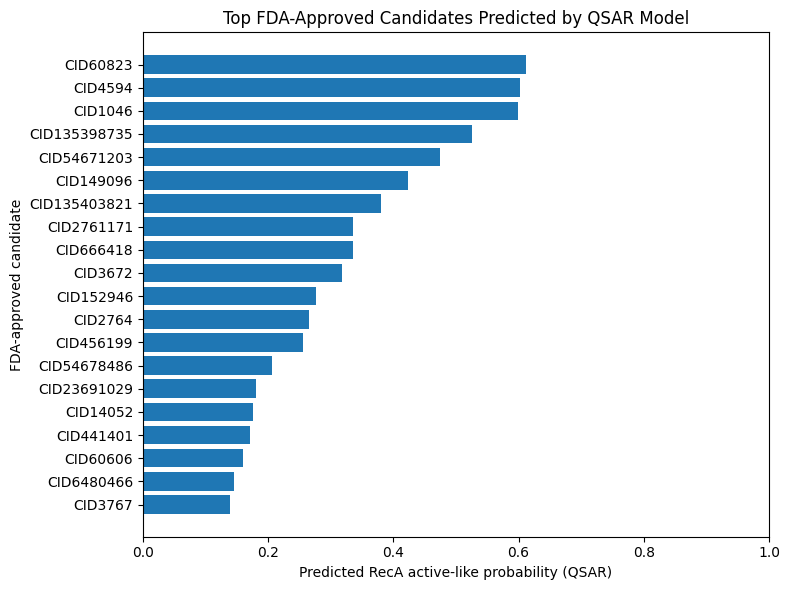

In [42]:
import matplotlib.pyplot as plt

# ============================================================
# 1.1 FDA prediction figure
# ============================================================

plot_df = fda_prediction_df.head(TOP_N_CANDIDATES).copy()
plot_df["candidate_label"] = plot_df["Name"].astype(str)

plt.figure(figsize=(8, 6))
plt.barh(
    plot_df["candidate_label"][::-1],
    plot_df["predicted_probability_active"][::-1],
)
plt.xlabel("Predicted RecA active-like probability (QSAR)")
plt.ylabel("FDA-approved candidate")
plt.title("Top FDA-Approved Candidates Predicted by QSAR Model")
plt.xlim(0, 1)
save_current_figure("03_top_fda_qsar_predictions.png")
plt.show()

###2. Bayesian Classification validation

This section applies a Good/Bad Fingerprint Bayesian classifier as a validation layer.
The Bayesian profile is fitted on the training split only for hold-out validation, then refitted on all labeled RecA data for FDA candidate scoring.

In [43]:
# ============================================================
# 2. Bayesian Good/Bad Fingerprint helper functions (REVISED)
# ============================================================

import numpy as np
import pandas as pd


def get_binary_fingerprint_columns(
    df: pd.DataFrame,
    features: list[str]
) -> list[str]:
    """
    Return selected features that behave as binary PaDEL fingerprint bits.
    """

    binary_features = []

    for feature in features:

        if feature not in df.columns:
            continue

        values = pd.to_numeric(
            df[feature],
            errors="coerce"
        ).dropna()

        if values.empty:
            continue

        unique_values = set(
            values.unique().astype(float)
        )

        if (
            unique_values.issubset({0.0, 1.0})
            and values.var() > 0
        ):
            binary_features.append(feature)

    return binary_features


def to_binary_matrix(
    df: pd.DataFrame,
    features: list[str]
) -> pd.DataFrame:
    """
    Convert fingerprint columns into binary 0/1 matrix.
    """

    return (
        clean_feature_matrix(df, features) > 0
    ).astype(int)


def compute_good_bad_fingerprint_table(
    X_binary: pd.DataFrame,
    y_binary: pd.Series,
    alpha: float = 2.0,
    min_occurrence: int = 5,
) -> pd.DataFrame:
    """
    Bayesian Good/Bad fingerprint enrichment table.

    Improvements:
    - stronger Laplace smoothing
    - remove extremely rare fingerprints
    """

    X_binary = (
        X_binary
        .reset_index(drop=True)
        .astype(int)
    )

    y_binary = (
        pd.Series(y_binary)
        .reset_index(drop=True)
        .astype(int)
    )

    active_mask = (y_binary == 1)
    inactive_mask = (y_binary == 0)

    n_active = int(active_mask.sum())
    n_inactive = int(inactive_mask.sum())

    rows = []

    for feature in X_binary.columns:

        active_count = int(
            X_binary.loc[
                active_mask,
                feature
            ].sum()
        )

        inactive_count = int(
            X_binary.loc[
                inactive_mask,
                feature
            ].sum()
        )

        total_count = (
            active_count +
            inactive_count
        )

        if total_count < min_occurrence:
            continue

        p_active = (
            active_count + alpha
        ) / (
            n_active + 2 * alpha
        )

        p_inactive = (
            inactive_count + alpha
        ) / (
            n_inactive + 2 * alpha
        )

        log_lr = float(
            np.log(
                p_active /
                p_inactive
            )
        )

        if log_lr > 0:
            fp_class = "good_active_enriched"

        elif log_lr < 0:
            fp_class = "bad_inactive_enriched"

        else:
            fp_class = "neutral"

        rows.append({

            "fingerprint": feature,

            "active_count": active_count,

            "inactive_count": inactive_count,

            "total_count": total_count,

            "p_bit_given_active": p_active,

            "p_bit_given_inactive": p_inactive,

            "log_likelihood_ratio": log_lr,

            "abs_log_likelihood_ratio": abs(log_lr),

            "bayesian_fingerprint_class": fp_class,

        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    return (
        result
        .sort_values(
            "abs_log_likelihood_ratio",
            ascending=False
        )
        .reset_index(drop=True)
    )


def sigmoid(x):

    x = np.asarray(
        x,
        dtype=float
    )

    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x))
    )


def score_samples_by_bayesian_fingerprints(
    X_binary: pd.DataFrame,
    bayesian_table: pd.DataFrame,
    prior_active: float,
) -> pd.DataFrame:
    """
    Bernoulli Naive Bayes Bayesian scoring.

    Uses BOTH:
    - fingerprint present (1)
    - fingerprint absent (0)

    This is statistically more correct than
    summing only positive fingerprint bits.
    """

    X_binary = (
        X_binary
        .astype(int)
        .copy()
    )

    fp_table = (
        bayesian_table
        .set_index("fingerprint")
        .copy()
    )

    common_features = [

        f

        for f in X_binary.columns

        if f in fp_table.index

    ]

    if len(common_features) == 0:

        return pd.DataFrame({

            "bayesian_log_score":
                np.zeros(len(X_binary)),

            "bayesian_probability_active_like":
                np.repeat(
                    prior_active,
                    len(X_binary)
                )

        })

    X = X_binary[
        common_features
    ].values

    p_active = (
        fp_table.loc[
            common_features,
            "p_bit_given_active"
        ]
        .values
    )

    p_inactive = (
        fp_table.loc[
            common_features,
            "p_bit_given_inactive"
        ]
        .values
    )

    eps = 1e-12

    p_active = np.clip(
        p_active,
        eps,
        1 - eps
    )

    p_inactive = np.clip(
        p_inactive,
        eps,
        1 - eps
    )

    log_prior_active = np.log(
        prior_active + eps
    )

    log_prior_inactive = np.log(
        1 - prior_active + eps
    )

    log_active = (

        log_prior_active

        +

        (
            X * np.log(p_active)

            +

            (1 - X)
            *
            np.log(1 - p_active)

        ).sum(axis=1)

    )

    log_inactive = (

        log_prior_inactive

        +

        (
            X * np.log(p_inactive)

            +

            (1 - X)
            *
            np.log(1 - p_inactive)

        ).sum(axis=1)

    )

    log_odds = (
        log_active
        -
        log_inactive
    )

    probability_active = sigmoid(
        log_odds
    )

    return pd.DataFrame({

        "bayesian_log_score":
            log_odds,

        "bayesian_probability_active_like":
            probability_active,

    })

In [44]:
# ============================================================
# 2.1 Hold-out Bayesian Classification validation (REVISED)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
)

# ------------------------------------------------------------
# Initialize data if necessary
# ------------------------------------------------------------

if (
    'training_df' not in globals()
    or 'X' not in globals()
    or 'y' not in globals()
    or 'X_train' not in globals()
    or 'X_test' not in globals()
    or 'y_train' not in globals()
    or 'y_test' not in globals()
):

    print("Initializing training data and train/test splits...")

    training_df = pd.read_csv(TRAINING_DATA_FILE)

    label_column = detect_label_column(
        training_df
    )

    non_feature_cols = [

        col

        for col in training_df.columns

        if col in [
            "Name",
            "canonical_smiles",
            "bioactivity_class",
            "class",
            label_column
        ]
    ]

    feature_cols = [

        col

        for col in training_df.columns

        if col not in non_feature_cols
    ]

    X = training_df[
        feature_cols
    ].copy()

    y = convert_label_to_binary(
        training_df[label_column]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

# ------------------------------------------------------------
# Binary fingerprints
# ------------------------------------------------------------

binary_features = get_binary_fingerprint_columns(
    training_df,
    selected_features
)

if len(binary_features) == 0:

    print(
        "No strict binary features found. "
        "Using value > 0 binarization."
    )

    binary_features = selected_features

X_binary_all = to_binary_matrix(
    training_df,
    binary_features
)

X_train_binary = (
    X_binary_all
    .loc[X_train.index, binary_features]
    .copy()
)

X_test_binary = (
    X_binary_all
    .loc[X_test.index, binary_features]
    .copy()
)

# ------------------------------------------------------------
# Train Bayesian model
# ------------------------------------------------------------

bayesian_train_table = (
    compute_good_bad_fingerprint_table(
        X_binary=X_train_binary,
        y_binary=y_train,
        alpha=2.0,
        min_occurrence=5,
    )
)

print(
    f"Bayesian fingerprints retained: "
    f"{len(bayesian_train_table):,}"
)

prior_active_train = float(
    y_train.mean()
)

# ------------------------------------------------------------
# Training probabilities
# ------------------------------------------------------------

train_scores = (
    score_samples_by_bayesian_fingerprints(
        X_binary=X_train_binary,
        bayesian_table=bayesian_train_table,
        prior_active=prior_active_train,
    )
)

train_proba = train_scores[
    "bayesian_probability_active_like"
].values

# ------------------------------------------------------------
# Optimal threshold
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_train,
    train_proba
)

youden = tpr - fpr

best_idx = np.argmax(
    youden
)

best_threshold = thresholds[
    best_idx
]

print(
    f"Optimal threshold = "
    f"{best_threshold:.4f}"
)

# ------------------------------------------------------------
# Test probabilities
# ------------------------------------------------------------

test_scores = (
    score_samples_by_bayesian_fingerprints(
        X_binary=X_test_binary,
        bayesian_table=bayesian_train_table,
        prior_active=prior_active_train,
    )
)

test_proba = test_scores[
    "bayesian_probability_active_like"
].values

test_pred = (
    test_proba >= best_threshold
).astype(int)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

specificity = (
    tn /
    (tn + fp)
)

sensitivity = (
    tp /
    (tp + fn)
)

# ------------------------------------------------------------
# Validation metrics
# ------------------------------------------------------------

bayesian_validation_results = pd.DataFrame([{

    "dataset":
        "holdout_test",

    "n_bayesian_features":
        len(binary_features),

    "optimal_threshold":
        best_threshold,

    "accuracy":
        accuracy_score(
            y_test,
            test_pred
        ),

    "balanced_accuracy":
        balanced_accuracy_score(
            y_test,
            test_pred
        ),

    "precision":
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "recall":
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "specificity":
        specificity,

    "f1_score":
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),

    "mcc":
        matthews_corrcoef(
            y_test,
            test_pred
        ),

    "roc_auc":
        roc_auc_score(
            y_test,
            test_proba
        ),

    "TP":
        tp,

    "FN":
        fn,

    "FP":
        fp,

    "TN":
        tn,

}])

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

save_table(
    bayesian_train_table,
    "04_bayesian_good_bad_fingerprint_table_train_split.csv"
)

save_table(
    bayesian_validation_results,
    "04_bayesian_classification_holdout_validation_results.csv"
)

print("\nBayesian Validation Summary")
print(
    bayesian_validation_results
)

display(
    bayesian_validation_results
)

display(
    bayesian_train_table.head(20)
)

Bayesian fingerprints retained: 100
Optimal threshold = 0.0110
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_good_bad_fingerprint_table_train_split.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_classification_holdout_validation_results.csv

Bayesian Validation Summary
        dataset  n_bayesian_features  optimal_threshold  accuracy  \
0  holdout_test                  100           0.010958  0.661202   

   balanced_accuracy  precision    recall  specificity  f1_score       mcc  \
0           0.692659   0.505051  0.793651     0.591667  0.617284  0.367386   

    roc_auc  TP  FN  FP  TN  
0  0.752513  50  13  49  71  


,dataset,n_bayesian_features,optimal_threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1_score,mcc,roc_auc,TP,FN,FP,TN
0,holdout_test,100,0.010958,0.661202,0.692659,0.505051,0.793651,0.591667,0.617284,0.367386,0.752513,50,13,49,71


,fingerprint,active_count,inactive_count,total_count,p_bit_given_active,p_bit_given_inactive,log_likelihood_ratio,abs_log_likelihood_ratio,bayesian_fingerprint_class
0,GraphFP517,27,152,179,0.113725,0.317526,-1.026771,1.026771,bad_inactive_enriched
1,GraphFP903,24,133,157,0.101961,0.278351,-1.004293,1.004293,bad_inactive_enriched
2,GraphFP858,95,66,161,0.380392,0.140206,0.998089,0.998089,good_active_enriched
3,GraphFP775,25,132,157,0.105882,0.276289,-0.959118,0.959118,bad_inactive_enriched
4,FP526,107,79,186,0.427451,0.167010,0.939784,0.939784,good_active_enriched
5,GraphFP740,25,128,153,0.105882,0.268041,-0.928812,0.928812,bad_inactive_enriched
6,FP315,23,116,139,0.098039,0.243299,-0.908923,0.908923,bad_inactive_enriched
7,GraphFP698,29,142,171,0.121569,0.296907,-0.892941,0.892941,bad_inactive_enriched
8,PubchemFP477,95,74,169,0.380392,0.156701,0.886863,0.886863,good_active_enriched
9,PubchemFP667,88,70,158,0.352941,0.148454,0.866029,0.866029,good_active_enriched


In [45]:
# ============================================================
# 2.2 Final Bayesian FDA Candidate Scoring (REVISED)
# ============================================================

# ------------------------------------------------------------
# Build final Bayesian model using ALL training compounds
# ------------------------------------------------------------

bayesian_full_table = (
    compute_good_bad_fingerprint_table(
        X_binary=X_binary_all,
        y_binary=y,
        alpha=2.0,
        min_occurrence=5,
    )
)

print(
    f"Final Bayesian fingerprints retained: "
    f"{len(bayesian_full_table):,}"
)

# ------------------------------------------------------------
# FDA fingerprint preparation
# ------------------------------------------------------------

fda_binary_features = [

    feature

    for feature in binary_features

    if feature in fda_fp_df.columns

]

if len(fda_binary_features) == 0:

    raise ValueError(
        "No Bayesian fingerprint features were found "
        "in the FDA fingerprint matrix."
    )

fda_binary = to_binary_matrix(
    fda_fp_df,
    fda_binary_features
)

# ------------------------------------------------------------
# Bayesian scoring
# ------------------------------------------------------------

fda_bayesian_scores = (
    score_samples_by_bayesian_fingerprints(
        X_binary=fda_binary,
        bayesian_table=bayesian_full_table[
            bayesian_full_table["fingerprint"].isin(
                fda_binary_features
            )
        ],
        prior_active=float(y.mean()),
    )
)

# ------------------------------------------------------------
# Merge QSAR + Bayesian
# ------------------------------------------------------------

fda_bayesian_df = pd.concat(
    [
        fda_prediction_df.reset_index(drop=True),
        fda_bayesian_scores.reset_index(drop=True),
    ],
    axis=1,
)

# ------------------------------------------------------------
# Normalize scores
# ------------------------------------------------------------

eps = 1e-12

fda_bayesian_df[
    "predicted_probability_active"
] = np.clip(
    fda_bayesian_df[
        "predicted_probability_active"
    ],
    eps,
    1.0,
)

fda_bayesian_df[
    "bayesian_probability_active_like"
] = np.clip(
    fda_bayesian_df[
        "bayesian_probability_active_like"
    ],
    eps,
    1.0,
)

# ------------------------------------------------------------
# Consensus score
# ------------------------------------------------------------

QSAR_WEIGHT = 0.60
BAYES_WEIGHT = 0.40

fda_bayesian_df[
    "combined_qsar_bayesian_score"
] = (

    QSAR_WEIGHT
    *
    fda_bayesian_df[
        "predicted_probability_active"
    ]

    +

    BAYES_WEIGHT
    *
    fda_bayesian_df[
        "bayesian_probability_active_like"
    ]

)

# ------------------------------------------------------------
# Bayesian confidence
# ------------------------------------------------------------

fda_bayesian_df[
    "bayesian_confidence"
] = np.abs(

    fda_bayesian_df[
        "bayesian_probability_active_like"
    ]

    - 0.50

)

# ------------------------------------------------------------
# High-confidence consensus score
# ------------------------------------------------------------

fda_bayesian_df[
    "consensus_confidence_score"
] = (

    fda_bayesian_df[
        "combined_qsar_bayesian_score"
    ]

    *

    (
        1.0
        +
        fda_bayesian_df[
            "bayesian_confidence"
        ]
    )

)

# ------------------------------------------------------------
# Rank candidates
# ------------------------------------------------------------

fda_bayesian_df = (

    fda_bayesian_df

    .sort_values(
        "consensus_confidence_score",
        ascending=False
    )

    .reset_index(drop=True)

)

fda_bayesian_df.insert(
    0,
    "bayesian_integrated_rank",
    np.arange(
        1,
        len(fda_bayesian_df) + 1
    )
)

# ------------------------------------------------------------
# Candidate classification
# ------------------------------------------------------------

fda_bayesian_df[
    "consensus_class"
] = np.where(

    fda_bayesian_df[
        "combined_qsar_bayesian_score"
    ] >= 0.80,

    "High-confidence candidate",

    np.where(

        fda_bayesian_df[
            "combined_qsar_bayesian_score"
        ] >= 0.60,

        "Promising candidate",

        "Low-priority candidate"

    )
)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

save_table(
    bayesian_full_table,
    "04_final_bayesian_good_bad_fingerprint_table_all_data.csv"
)

save_table(
    fda_bayesian_df,
    "04_fda_predictions_with_bayesian_classification.csv"
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

bayes_display_cols = [

    c

    for c in [

        "bayesian_integrated_rank",

        "Name",

        "cid",

        "predicted_probability_active",

        "bayesian_probability_active_like",

        "combined_qsar_bayesian_score",

        "consensus_confidence_score",

        "consensus_class",

        "predicted_label",

    ]

    if c in fda_bayesian_df.columns

]

display(
    fda_bayesian_df[
        bayes_display_cols
    ].head(
        TOP_N_CANDIDATES
    )
)

print("\nTop FDA candidates identified:")
print(
    fda_bayesian_df[
        bayes_display_cols
    ].head(10)
)

Final Bayesian fingerprints retained: 100
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_final_bayesian_good_bad_fingerprint_table_all_data.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_fda_predictions_with_bayesian_classification.csv


,bayesian_integrated_rank,Name,cid,predicted_probability_active,bayesian_probability_active_like,combined_qsar_bayesian_score,consensus_confidence_score,consensus_class,predicted_label
0,1,CID135398735,135398735.0,0.525396,9.730169e-01,0.704445,1.037659,Promising candidate,active_like
1,2,CID6480466,6480466.0,0.145574,9.859449e-01,0.481722,0.715813,Low-priority candidate,inactive_like
2,3,CID60823,60823.0,0.612554,5.941677e-05,0.367556,0.551312,Low-priority candidate,active_like
3,4,CID4594,4594.0,0.602270,1.016531e-03,0.361769,0.542285,Low-priority candidate,active_like
4,5,CID1046,1046.0,0.598612,1.095448e-08,0.359167,0.538751,Low-priority candidate,active_like
5,6,CID456199,456199.0,0.255121,6.847491e-01,0.426972,0.505855,Low-priority candidate,inactive_like
6,7,CID4091,4091.0,0.024607,8.716904e-01,0.363441,0.498528,Low-priority candidate,inactive_like
7,8,CID54671203,54671203.0,0.475213,4.270807e-07,0.285128,0.427692,Low-priority candidate,inactive_like
8,9,CID135415564,135415564.0,0.106787,7.151863e-01,0.350147,0.425493,Low-priority candidate,inactive_like
9,10,CID149096,149096.0,0.424188,1.200732e-05,0.254518,0.381774,Low-priority candidate,inactive_like



Top FDA candidates identified:
   bayesian_integrated_rank          Name          cid  \
0                         1  CID135398735  135398735.0   
1                         2    CID6480466    6480466.0   
2                         3      CID60823      60823.0   
3                         4       CID4594       4594.0   
4                         5       CID1046       1046.0   
5                         6     CID456199     456199.0   
6                         7       CID4091       4091.0   
7                         8   CID54671203   54671203.0   
8                         9  CID135415564  135415564.0   
9                        10     CID149096     149096.0   

   predicted_probability_active  bayesian_probability_active_like  \
0                      0.525396                      9.730169e-01   
1                      0.145574                      9.859449e-01   
2                      0.612554                      5.941677e-05   
3                      0.602270                      

In [46]:
# ============================================================
# Bayesian Feature Number Optimization (REVISED)
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.naive_bayes import BernoulliNB

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

FEATURE_RANGE = list(
    range(10, 101, 10)
)

ALPHA_GRID = [
    0.5,
    1.0,
    2.0,
    5.0
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# ------------------------------------------------------------
# Ranked Bayesian fingerprints
# ------------------------------------------------------------

ranked_features = (
    bayesian_full_table
    .sort_values(
        "abs_log_likelihood_ratio",
        ascending=False
    )
    ["fingerprint"]
    .tolist()
)

ranked_features = [

    f

    for f in ranked_features

    if f in X_binary_all.columns

]

optimization_results = []

# ------------------------------------------------------------
# Grid search
# ------------------------------------------------------------

for alpha in ALPHA_GRID:

    for n_features in FEATURE_RANGE:

        selected_features = (
            ranked_features[:n_features]
        )

        X_bayes = (
            X_binary_all[
                selected_features
            ]
            .copy()
        )

        model = BernoulliNB(
            alpha=alpha
        )

        scores = cross_validate(

            model,

            X_bayes,

            y,

            cv=cv,

            n_jobs=-1,

            scoring={

                "roc_auc":
                    "roc_auc",

                "accuracy":
                    "accuracy",

                "balanced_accuracy":
                    "balanced_accuracy",

                "f1":
                    "f1",

                "mcc":
                    "matthews_corrcoef",

            },

            return_train_score=False,

        )

        optimization_results.append({

            "alpha":
                alpha,

            "n_features":
                n_features,

            "mean_cv_roc_auc":
                np.mean(
                    scores["test_roc_auc"]
                ),

            "sd_cv_roc_auc":
                np.std(
                    scores["test_roc_auc"]
                ),

            "mean_cv_accuracy":
                np.mean(
                    scores["test_accuracy"]
                ),

            "mean_cv_balanced_accuracy":
                np.mean(
                    scores["test_balanced_accuracy"]
                ),

            "mean_cv_f1":
                np.mean(
                    scores["test_f1"]
                ),

            "mean_cv_mcc":
                np.mean(
                    scores["test_mcc"]
                ),

        })

# ------------------------------------------------------------
# Results dataframe
# ------------------------------------------------------------

bayes_optimization_df = pd.DataFrame(
    optimization_results
)

# ------------------------------------------------------------
# Select best model
# ------------------------------------------------------------

best_row = (

    bayes_optimization_df

    .sort_values(

        [
            "mean_cv_roc_auc",
            "mean_cv_mcc"
        ],

        ascending=False

    )

    .iloc[0]

)

BEST_ALPHA = float(
    best_row["alpha"]
)

BEST_N_FEATURES = int(
    best_row["n_features"]
)

BEST_ROC = float(
    best_row["mean_cv_roc_auc"]
)

BEST_MCC = float(
    best_row["mean_cv_mcc"]
)

BEST_ACC = float(
    best_row["mean_cv_accuracy"]
)

BEST_BAL_ACC = float(
    best_row["mean_cv_balanced_accuracy"]
)

BEST_F1 = float(
    best_row["mean_cv_f1"]
)

best_bayesian_features = (
    ranked_features[
        :BEST_N_FEATURES
    ]
)

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("\n==============================")
print("BEST BAYESIAN MODEL")
print("==============================")

print(
    f"Best Alpha       : {BEST_ALPHA}"
)

print(
    f"Best Features    : {BEST_N_FEATURES}"
)

print(
    f"Best ROC-AUC     : {BEST_ROC:.4f}"
)

print(
    f"Best MCC         : {BEST_MCC:.4f}"
)

print(
    f"Best Accuracy    : {BEST_ACC:.4f}"
)

print(
    f"Best Bal Accuracy: {BEST_BAL_ACC:.4f}"
)

print(
    f"Best F1 Score    : {BEST_F1:.4f}"
)

display(
    bayes_optimization_df
)

# ------------------------------------------------------------
# Save optimization table
# ------------------------------------------------------------

bayes_optimization_df.to_csv(

    OUTPUT_DIR
    /
    "bayesian_feature_number_optimization.csv",

    index=False

)

# ------------------------------------------------------------
# Save best features
# ------------------------------------------------------------

pd.DataFrame({

    "rank":
        np.arange(
            1,
            BEST_N_FEATURES + 1
        ),

    "selected_bayesian_feature":
        best_bayesian_features

}).to_csv(

    OUTPUT_DIR
    /
    f"best_bayesian_features_top_{BEST_N_FEATURES}.csv",

    index=False

)

# ------------------------------------------------------------
# Store globals
# ------------------------------------------------------------

BEST_BAYESIAN_ALPHA = (
    BEST_ALPHA
)

BEST_BAYESIAN_N_FEATURES = (
    BEST_N_FEATURES
)

BEST_BAYESIAN_FEATURES = (
    best_bayesian_features
)

print(
    "\nBest Bayesian feature set saved."
)


BEST BAYESIAN MODEL
Best Alpha       : 1.0
Best Features    : 100
Best ROC-AUC     : 0.7752
Best MCC         : 0.3779
Best Accuracy    : 0.7191
Best Bal Accuracy: 0.6881
Best F1 Score    : 0.5904


,alpha,n_features,mean_cv_roc_auc,sd_cv_roc_auc,mean_cv_accuracy,mean_cv_balanced_accuracy,mean_cv_f1,mean_cv_mcc
0,0.5,10,0.730184,0.028647,0.636066,0.656927,0.578007,0.299962
1,0.5,20,0.761144,0.026275,0.653552,0.683115,0.607539,0.349387
2,0.5,30,0.766299,0.026778,0.636066,0.668250,0.593887,0.321461
3,0.5,40,0.758846,0.017049,0.672131,0.688870,0.609568,0.360134
4,0.5,50,0.752232,0.014742,0.692896,0.690381,0.602110,0.367416
5,0.5,60,0.760269,0.016610,0.697268,0.692926,0.605040,0.371896
6,0.5,70,0.765017,0.018999,0.708197,0.691205,0.599683,0.375065
7,0.5,80,0.762570,0.021489,0.706011,0.675779,0.574861,0.351251
8,0.5,90,0.771358,0.022810,0.718033,0.684948,0.585682,0.373744
9,0.5,100,0.775146,0.023263,0.719126,0.688076,0.590385,0.377892



Best Bayesian feature set saved.


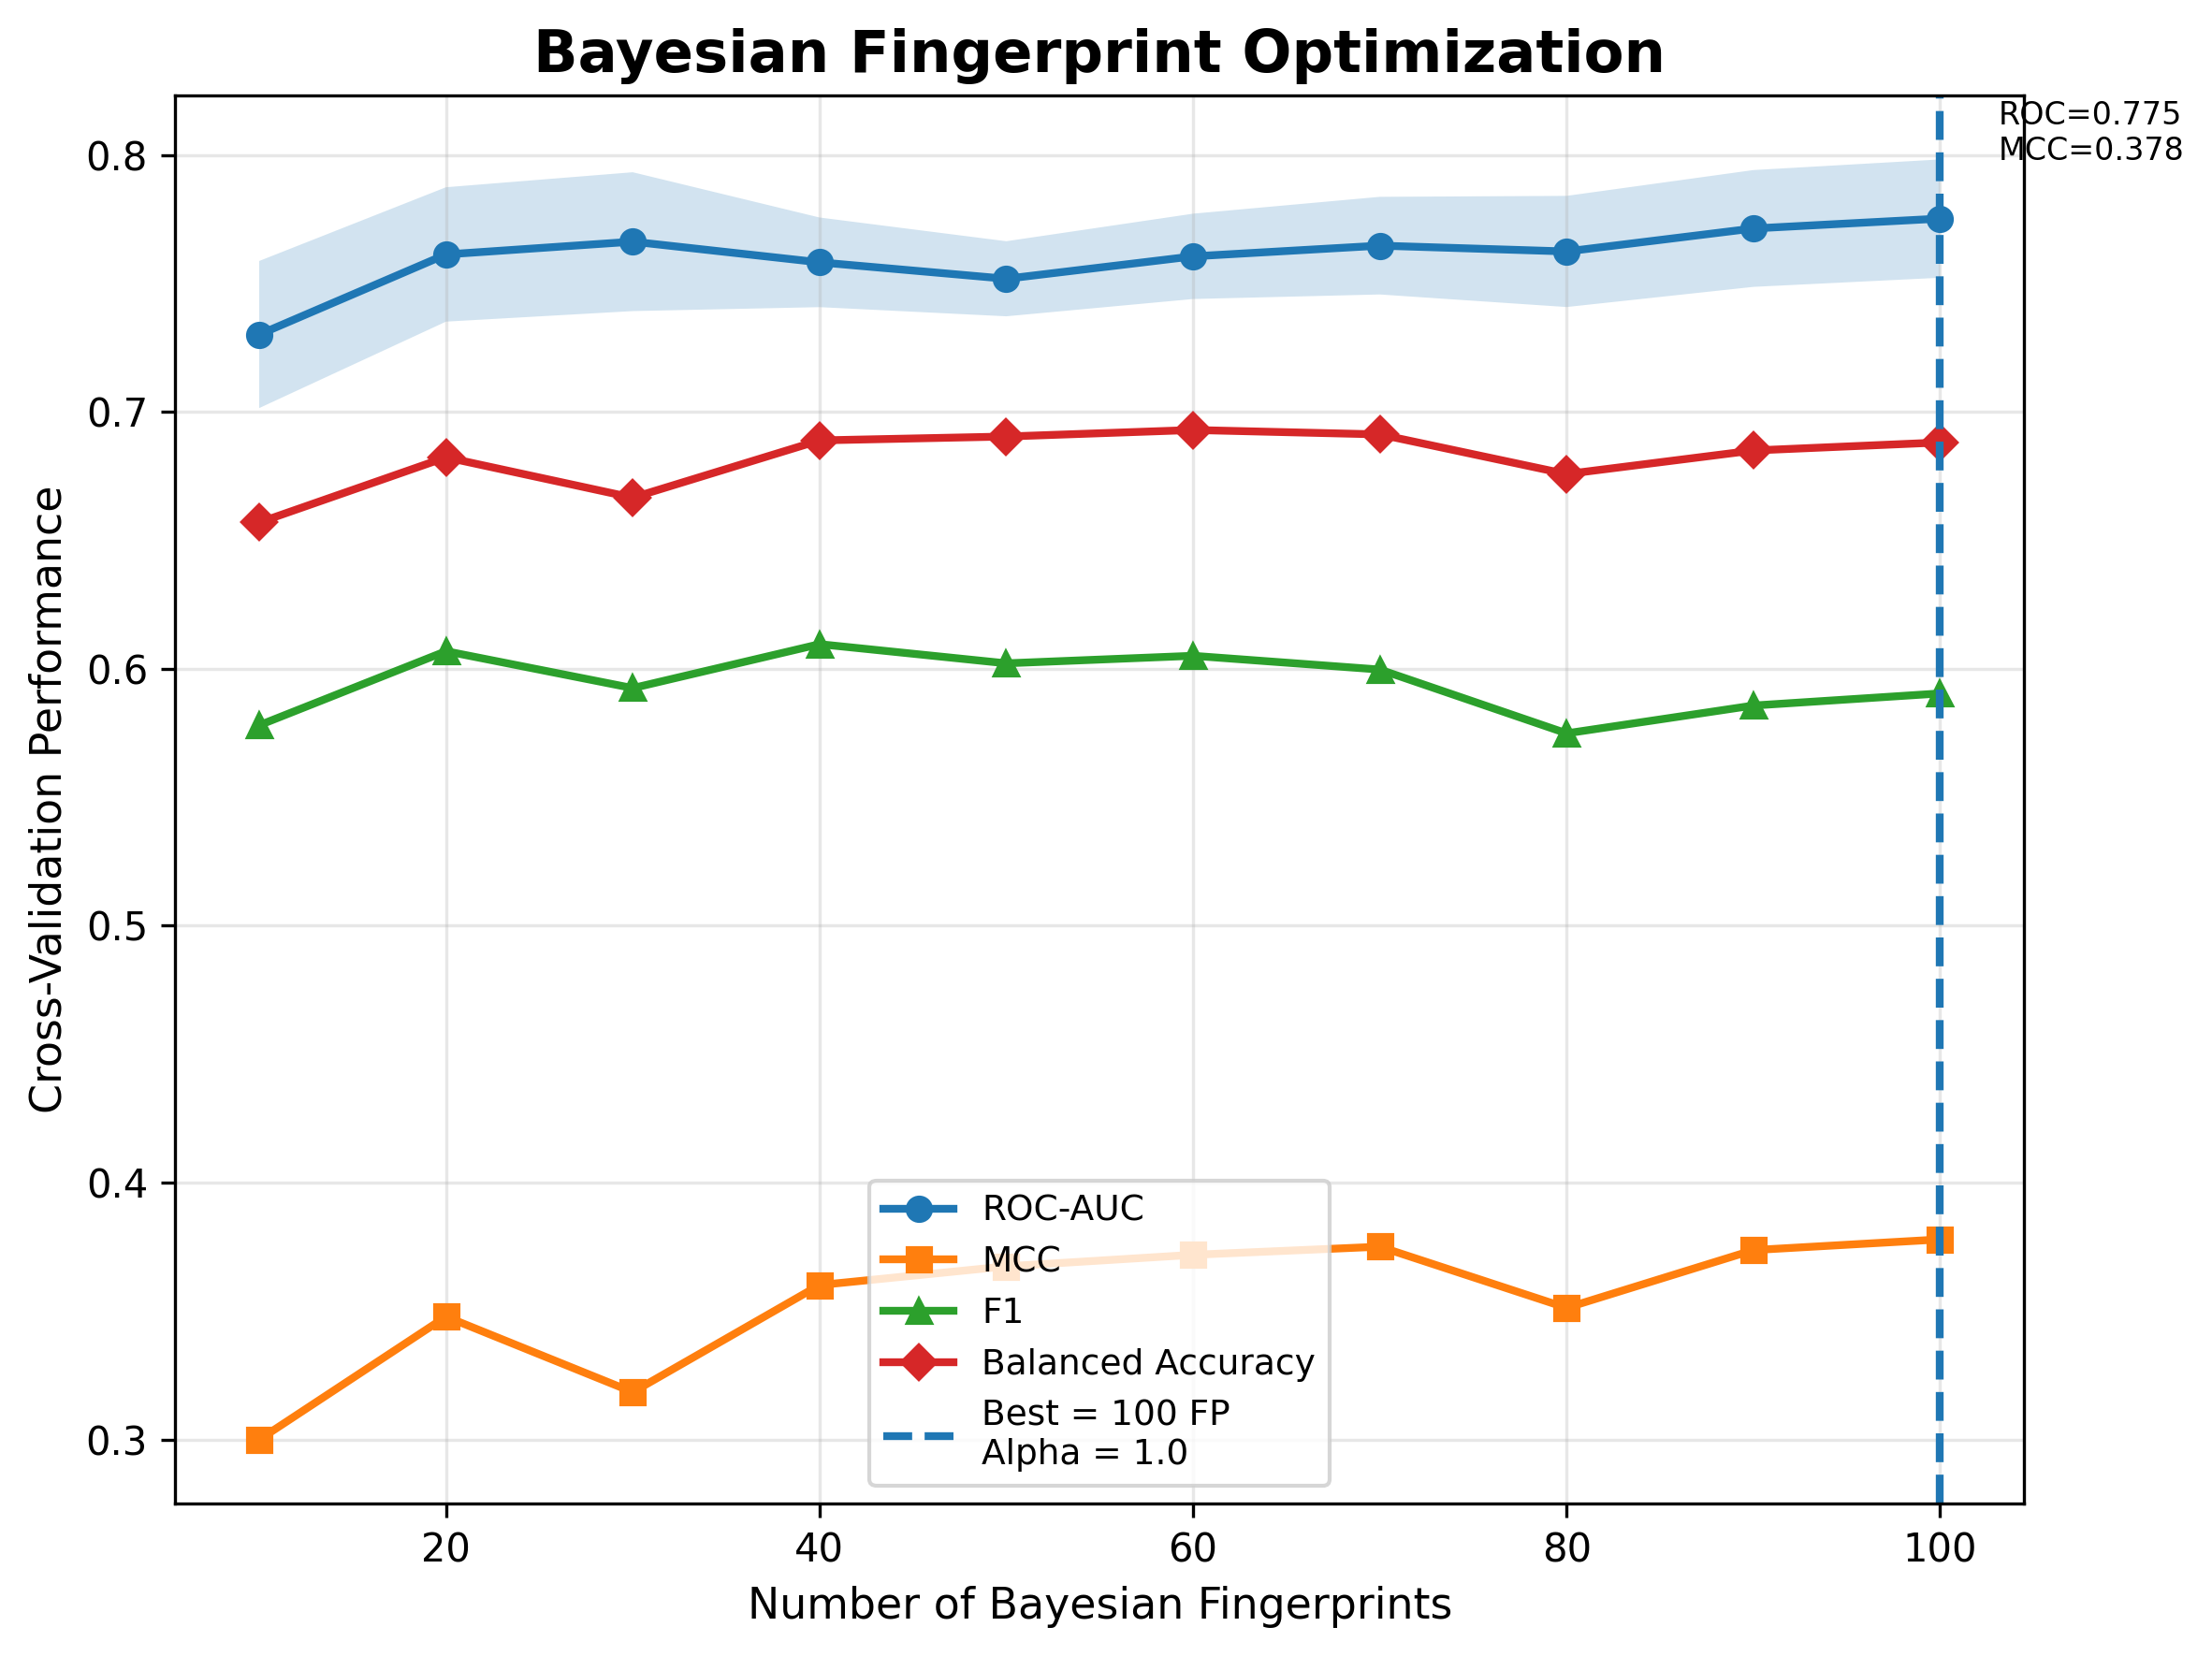


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_feature_optimization_publication.png


In [47]:
# ============================================================
# Bayesian Feature Optimization Plot
# ============================================================

DIAGNOSTIC_DIR = FIGURE_DIR

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Best alpha result
# ------------------------------------------------------------

best_alpha_df = (
    bayes_optimization_df[
        bayes_optimization_df["alpha"] == BEST_BAYESIAN_ALPHA
    ]
    .sort_values("n_features")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6),
    dpi=300
)

# ROC-AUC

ax.plot(
    best_alpha_df["n_features"],
    best_alpha_df["mean_cv_roc_auc"],
    marker="o",
    linewidth=2,
    label="ROC-AUC"
)

ax.fill_between(
    best_alpha_df["n_features"],
    best_alpha_df["mean_cv_roc_auc"]
    -
    best_alpha_df["sd_cv_roc_auc"],
    best_alpha_df["mean_cv_roc_auc"]
    +
    best_alpha_df["sd_cv_roc_auc"],
    alpha=0.20
)

# MCC

ax.plot(
    best_alpha_df["n_features"],
    best_alpha_df["mean_cv_mcc"],
    marker="s",
    linewidth=2,
    label="MCC"
)

# F1

ax.plot(
    best_alpha_df["n_features"],
    best_alpha_df["mean_cv_f1"],
    marker="^",
    linewidth=2,
    label="F1"
)

# Balanced Accuracy

ax.plot(
    best_alpha_df["n_features"],
    best_alpha_df["mean_cv_balanced_accuracy"],
    marker="D",
    linewidth=2,
    label="Balanced Accuracy"
)

# Best feature number

ax.axvline(
    BEST_BAYESIAN_N_FEATURES,
    linestyle="--",
    linewidth=2,
    label=(
        f"Best = {BEST_BAYESIAN_N_FEATURES} FP\n"
        f"Alpha = {BEST_BAYESIAN_ALPHA}"
    )
)

# Annotation

best_row = best_alpha_df[
    best_alpha_df["n_features"]
    ==
    BEST_BAYESIAN_N_FEATURES
].iloc[0]

ax.annotate(
    (
        f"ROC={best_row['mean_cv_roc_auc']:.3f}\n"
        f"MCC={best_row['mean_cv_mcc']:.3f}"
    ),
    (
        BEST_BAYESIAN_N_FEATURES,
        best_row["mean_cv_roc_auc"]
    ),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=8,
)

# Labels

ax.set_xlabel(
    "Number of Bayesian Fingerprints",
    fontsize=11
)

ax.set_ylabel(
    "Cross-Validation Performance",
    fontsize=11
)

ax.set_title(
    "Bayesian Fingerprint Optimization",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    frameon=True,
    fontsize=9
)

fig.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.savefig(
    DIAGNOSTIC_DIR /
    "bayesian_feature_optimization_publication.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

print(
    "\nSaved:",
    DIAGNOSTIC_DIR /
    "bayesian_feature_optimization_publication.png"
)

###3. Bayesian Classification fgures

This section adds deeper Bayesian Classification diagnostics inspired by published Good/Bad fingerprint analysis.
It generates compact, manuscript-style figures for:

* Bayesian statistical performance summary
* Top 20 good active-enriched fingerprints
* Top 20 bad inactive-enriched fingerprints
* Representative active compounds carrying good fingerprints
* Representative inactive compounds carrying bad fingerprints
* A simple decision-tree surrogate to visualize fingerprint-based class separation

These figures are intended for interpretation and supplementary analysis. Use only the most important ones in the main manuscript.

RDKit is not available. Text-based figures will be generated only.
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_top20_good_active_enriched_bayesian_fingerprints.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_top20_bad_inactive_enriched_bayesian_fingerprints.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_table6_like_validation_statistics_training_test.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04A_bayesian_validation_statistics_training_test_table.png


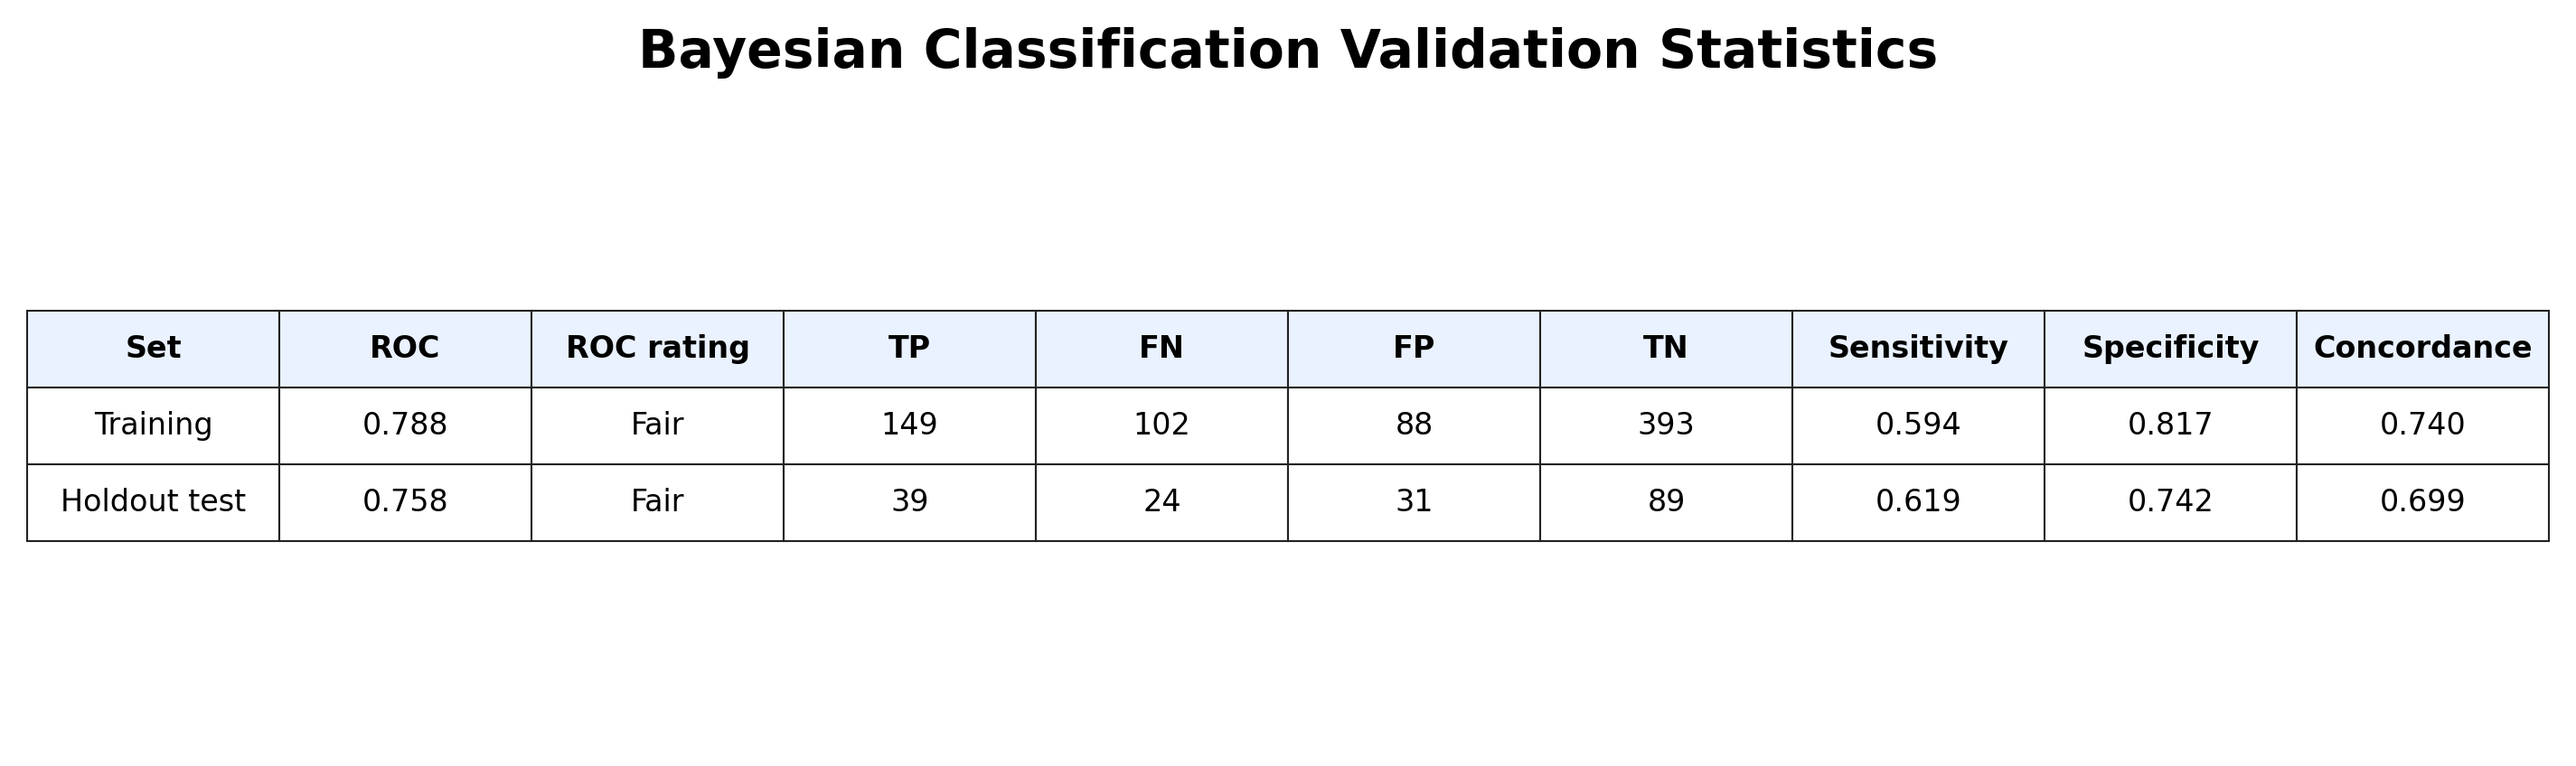

,Set,ROC,ROC rating,TP,FN,FP,TN,Sensitivity,Specificity,Concordance
0,Training,0.788186,Fair,149,102,88,393,0.593625,0.817048,0.740437
1,Holdout test,0.758267,Fair,39,24,31,89,0.619048,0.741667,0.699454


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04B_top20_good_active_enriched_bayesian_fingerprints.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04B_top20_good_active_enriched_bayesian_fingerprints.png


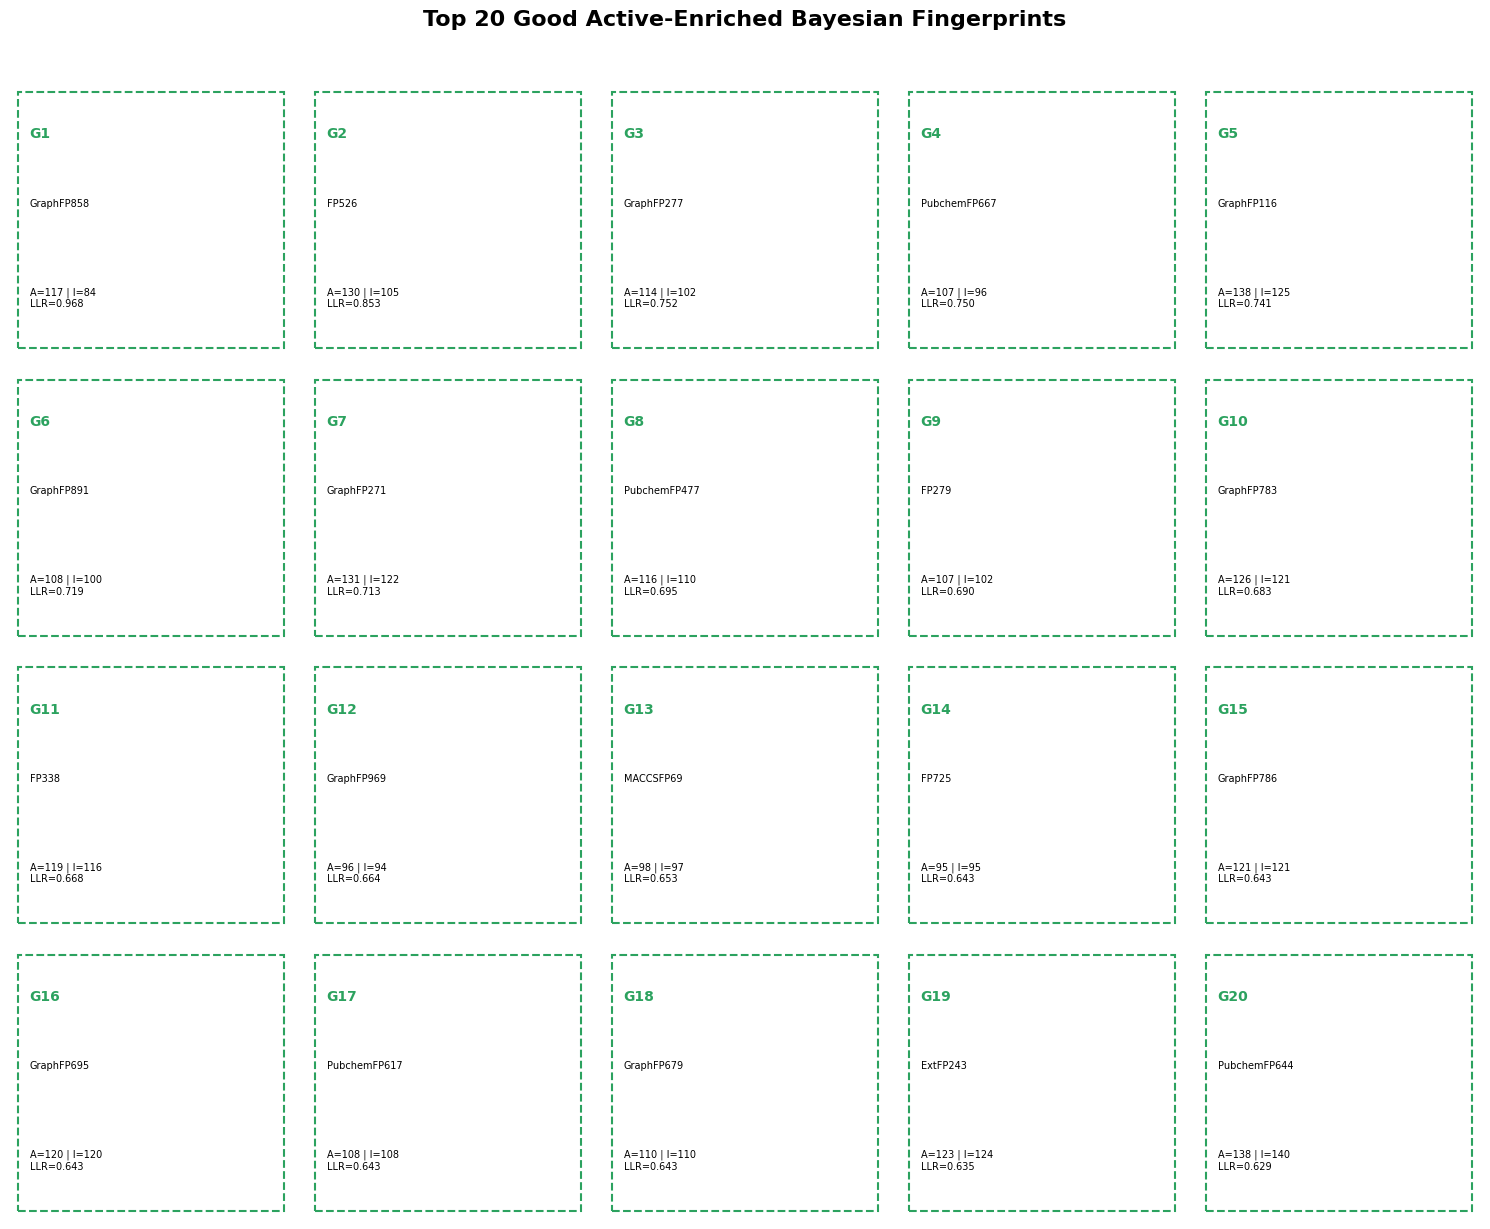

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04C_top20_bad_inactive_enriched_bayesian_fingerprints.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04C_top20_bad_inactive_enriched_bayesian_fingerprints.png


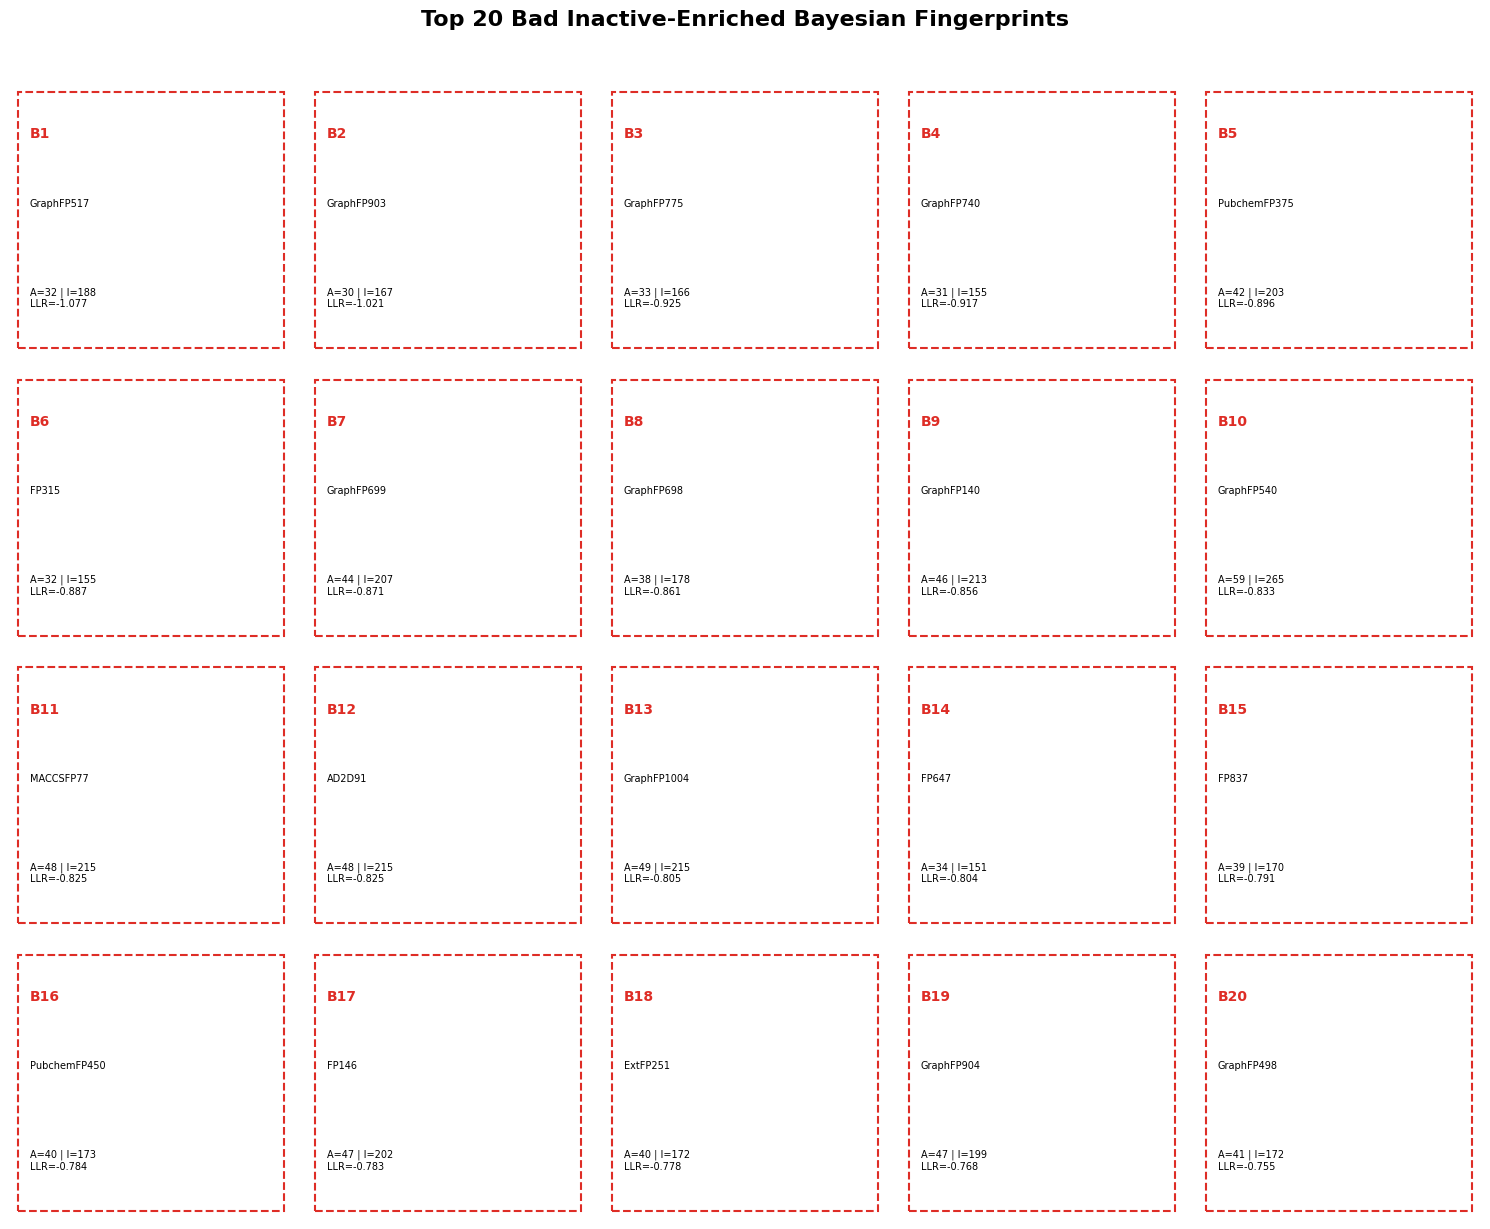

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04D_active_compounds_with_good_bayesian_evidence.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04D_active_compounds_with_good_bayesian_evidence.png


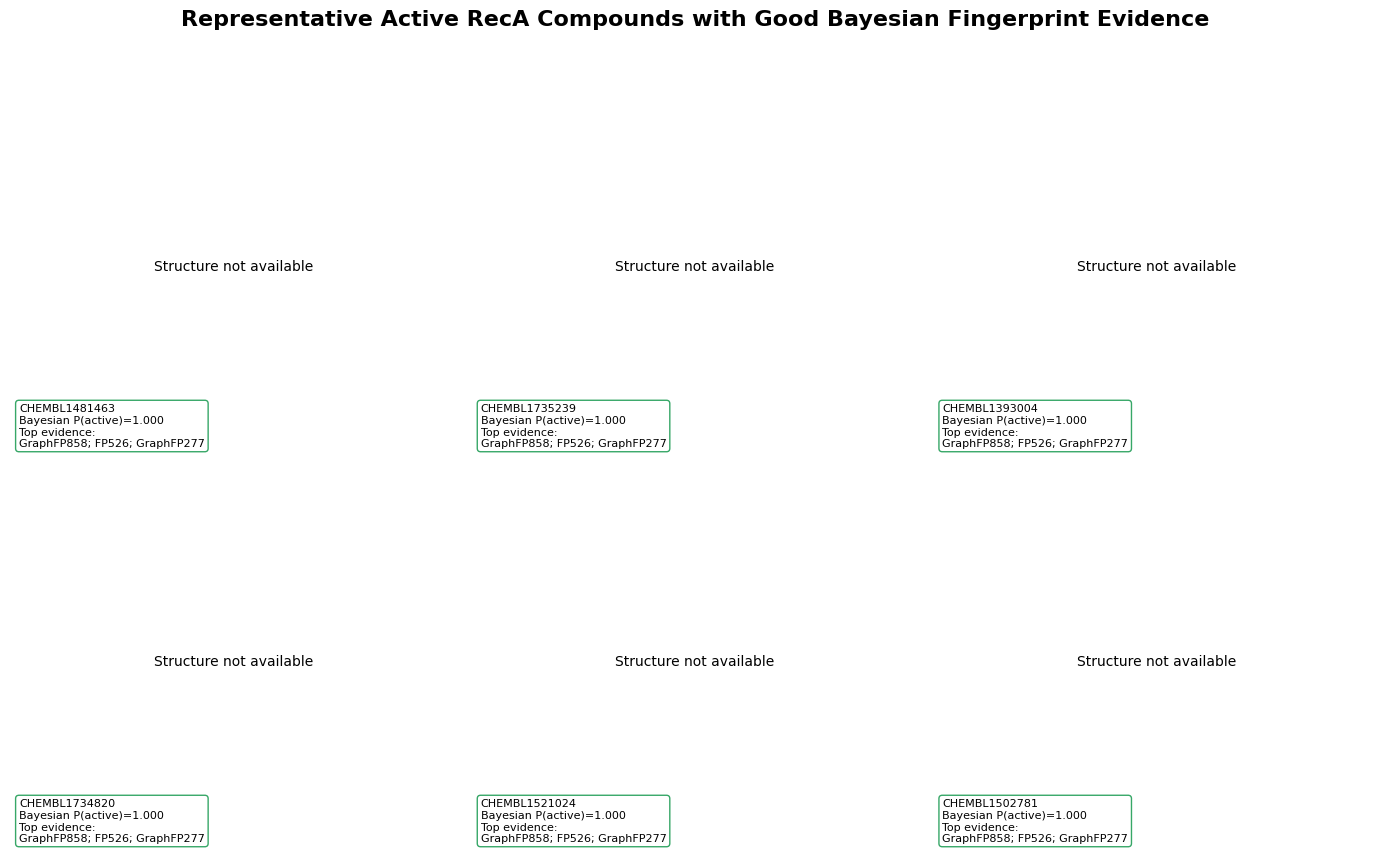

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04E_inactive_compounds_with_bad_bayesian_evidence.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04E_inactive_compounds_with_bad_bayesian_evidence.png


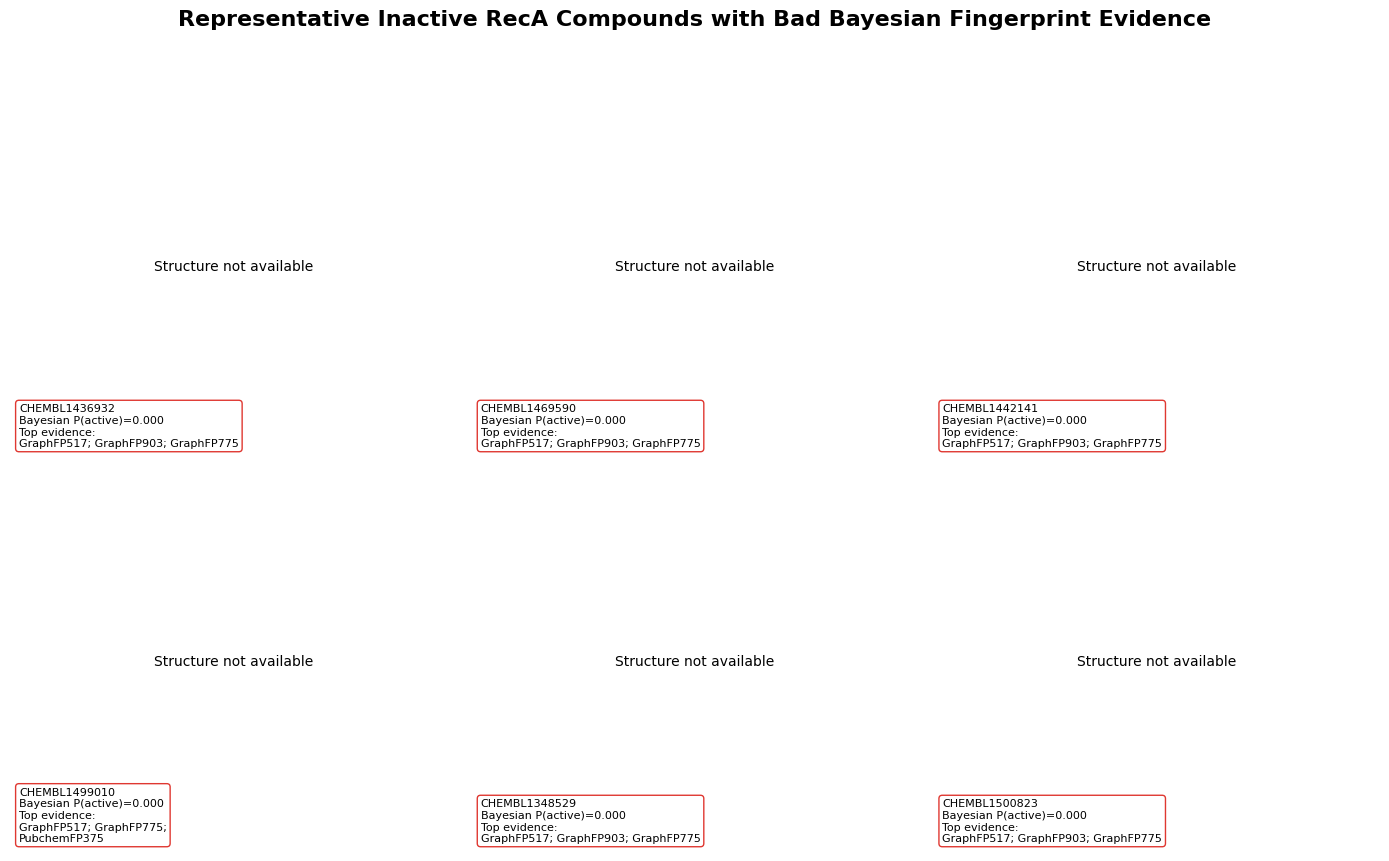

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04F_bayesian_decision_tree_surrogate.png


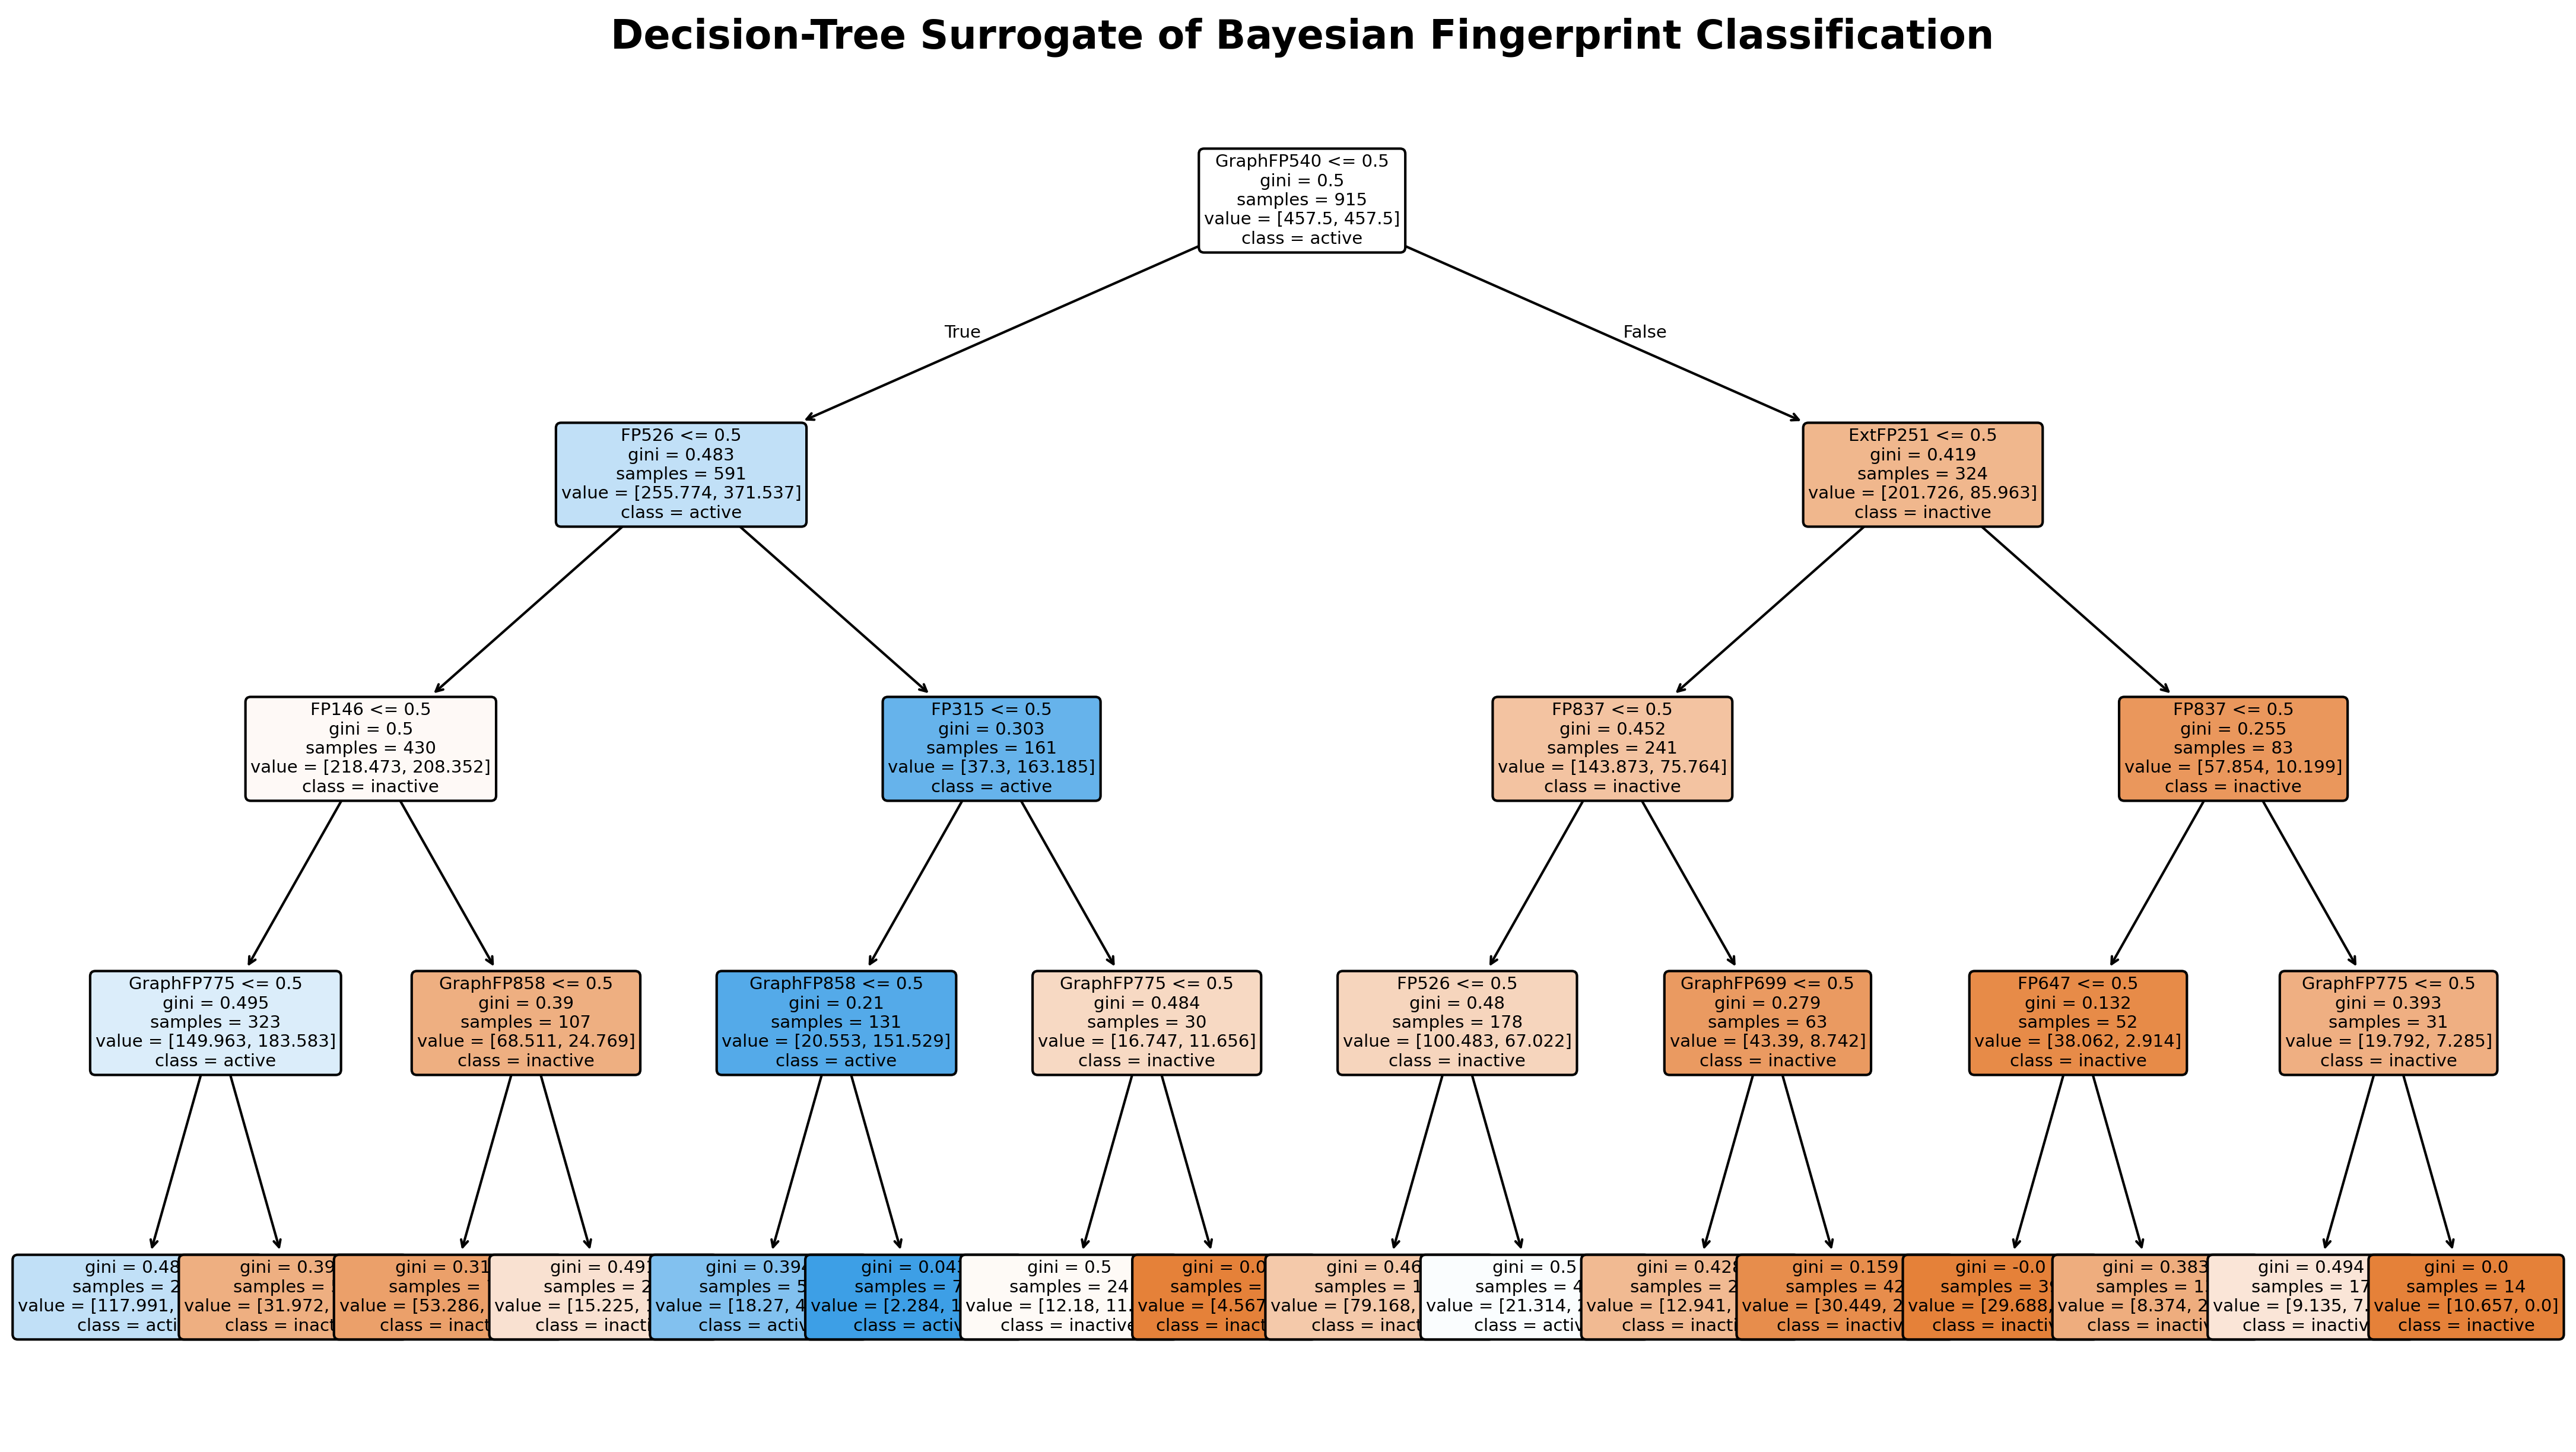

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_decision_tree_surrogate_feature_importance.csv


,feature,importance
11,GraphFP540,0.287253
10,FP526,0.255953
3,GraphFP775,0.105105
18,FP146,0.100032
6,FP315,0.091143
2,GraphFP858,0.060617
16,FP837,0.047125
19,ExtFP251,0.033438
7,GraphFP699,0.010117
15,FP647,0.009217


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_fda_top_candidates_with_bayesian_fingerprint_evidence.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures/04G_fda_top_candidates_with_bayesian_evidence_table.png


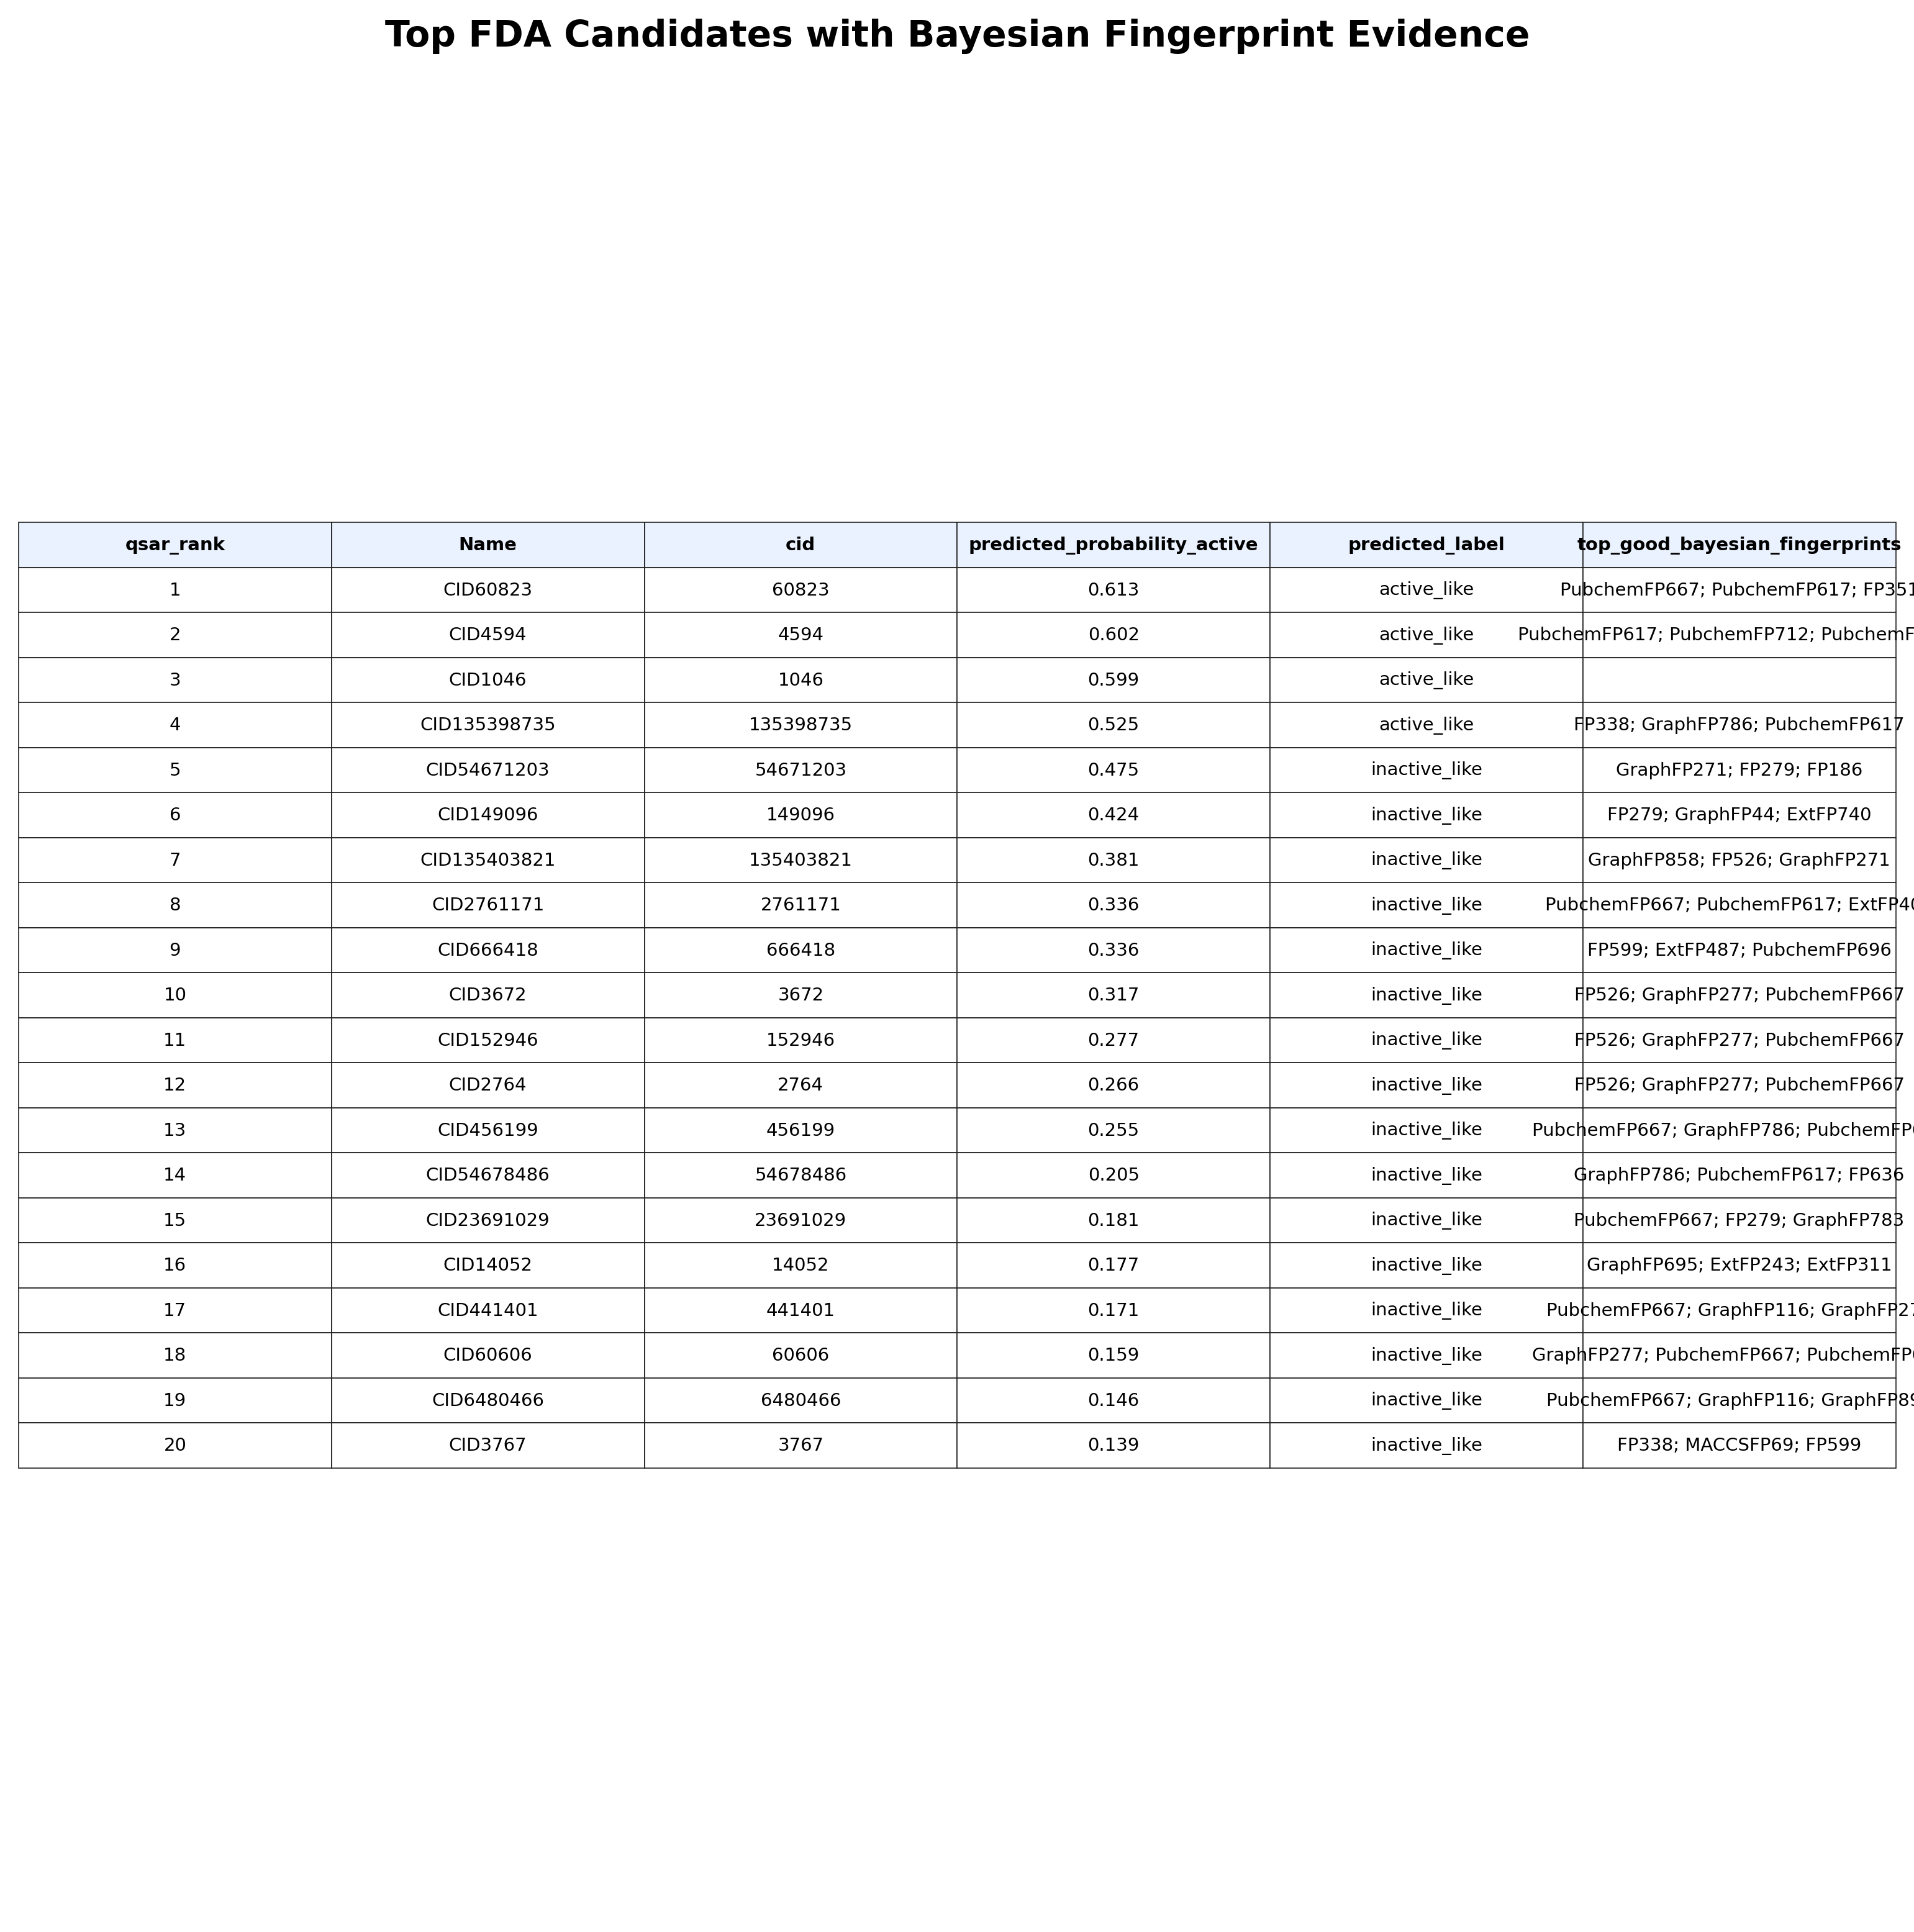

,qsar_rank,Name,cid,predicted_probability_active,predicted_label,top_good_bayesian_fingerprints,top_bad_bayesian_fingerprints
0,1,CID60823,60823,0.612554,active_like,PubchemFP667; PubchemFP617; FP351,GraphFP140; GraphFP641; GraphFP489
1,2,CID4594,4594,0.602270,active_like,PubchemFP617; PubchemFP712; PubchemFP696,FP645; ExtFP953
2,3,CID1046,1046,0.598612,active_like,,PubchemFP375; GraphFP699; GraphFP698
3,4,CID135398735,135398735,0.525396,active_like,FP338; GraphFP786; PubchemFP617,ExtFP251; ExtFP846; FP645
4,5,CID54671203,54671203,0.475213,inactive_like,GraphFP271; FP279; FP186,GraphFP140; GraphFP540; FP837
5,6,CID149096,149096,0.424188,inactive_like,FP279; GraphFP44; ExtFP740,GraphFP140; FP146; ExtFP251
6,7,CID135403821,135403821,0.380805,inactive_like,GraphFP858; FP526; GraphFP271,GraphFP517; GraphFP903; GraphFP775
7,8,CID2761171,2761171,0.336331,inactive_like,PubchemFP667; PubchemFP617; ExtFP404,GraphFP517; GraphFP903; GraphFP775
8,9,CID666418,666418,0.336331,inactive_like,FP599; ExtFP487; PubchemFP696,GraphFP517; PubchemFP375; GraphFP699
9,10,CID3672,3672,0.317473,inactive_like,FP526; GraphFP277; PubchemFP667,FP146; ExtFP194; FP1005


Bayesian publication-ready figures generated in: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/bayesian_publication_figures


In [48]:
# ============================================================
# 3. Publication-ready Bayesian Classification figures
# Training + Test validation, ROC rating, Good/Bad fingerprints,
# and FDA candidate Bayesian evidence
# ============================================================

try:
    from rdkit import Chem
    from rdkit.Chem import Draw
    RDKIT_AVAILABLE = True
except Exception:
    RDKIT_AVAILABLE = False
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rdkit-pypi"])
        from rdkit import Chem
        from rdkit.Chem import Draw
        RDKIT_AVAILABLE = True
    except Exception as exc:
        print("RDKit is not available. Text-based figures will be generated only.")
        RDKIT_AVAILABLE = False

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import textwrap

BAYESIAN_FIG_DIR = DIAGNOSTIC_DIR / "bayesian_publication_figures"
BAYESIAN_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _save_bayesian_fig(filename):
    out_path = BAYESIAN_FIG_DIR / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")
    return out_path


def _roc_rating(roc):
    if roc >= 0.90:
        return "Excellent"
    elif roc >= 0.80:
        return "Good"
    elif roc >= 0.70:
        return "Fair"
    elif roc >= 0.60:
        return "Poor"
    else:
        return "Fail"


def _find_smiles_column(df):
    for col in ["canonical_smiles", "SMILES", "smiles", "Canonical_SMILES", "canonical_smile"]:
        if col in df.columns:
            return col
    return None


def _find_name_column(df):
    for col in ["molecule_chembl_id", "Name", "compound_name", "ChEMBL_ID", "chembl_id", "cid"]:
        if col in df.columns:
            return col
    return None


def _safe_short_label(text, width=24):
    text = str(text)
    return "\n".join(textwrap.wrap(text, width=width)) if len(text) > width else text


def _mol_from_smiles(smiles):
    if not RDKIT_AVAILABLE or pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def _draw_text_card(ax, title, subtitle, score, border_color="#2ca25f"):
    ax.axis("off")
    rect = plt.Rectangle(
        (0.03, 0.03), 0.94, 0.94,
        fill=False,
        linewidth=1.5,
        linestyle="--",
        edgecolor=border_color
    )
    ax.add_patch(rect)
    ax.text(0.07, 0.80, title, fontsize=10, fontweight="bold", color=border_color, transform=ax.transAxes)
    ax.text(0.07, 0.55, _safe_short_label(subtitle, 22), fontsize=7, transform=ax.transAxes)
    ax.text(0.07, 0.18, score, fontsize=7, transform=ax.transAxes)


def _bayesian_score_for_indexed_data(X_input, prior_active):
    return score_samples_by_bayesian_fingerprints(
        X_binary=X_input[binary_features],
        bayesian_table=bayesian_full_table[
            bayesian_full_table["fingerprint"].isin(binary_features)
        ],
        prior_active=float(prior_active),
    )


def _bayes_validation_row(set_name, y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    roc = roc_auc_score(y_true, y_proba)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    concordance = accuracy_score(y_true, y_pred)

    return {
        "Set": set_name,
        "ROC": roc,
        "ROC rating": _roc_rating(roc),
        "TP": int(tp),
        "FN": int(fn),
        "FP": int(fp),
        "TN": int(tn),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Concordance": concordance,
    }


def plot_bayesian_validation_table():
    """
    Training + holdout test Bayesian validation table.
    """

    train_score_df = _bayesian_score_for_indexed_data(
        X_binary_all.loc[X_train.index],
        prior_active=float(y_train.mean())
    )

    train_proba = train_score_df["bayesian_probability_active_like"].values
    train_pred = (train_proba >= 0.5).astype(int)

    test_score_df = _bayesian_score_for_indexed_data(
        X_binary_all.loc[X_test.index],
        prior_active=float(y_train.mean())
    )

    test_proba = test_score_df["bayesian_probability_active_like"].values
    test_pred = (test_proba >= 0.5).astype(int)

    table_df = pd.DataFrame([
        _bayes_validation_row("Training", y_train, train_pred, train_proba),
        _bayes_validation_row("Holdout test", y_test, test_pred, test_proba),
    ])

    save_table(
        table_df,
        "04_bayesian_table6_like_validation_statistics_training_test.csv"
    )

    fig, ax = plt.subplots(figsize=(12, 3.0), dpi=300)
    ax.axis("off")

    ax.set_title(
        "Bayesian Classification Validation Statistics",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    display_df = table_df.copy()
    for col in ["ROC", "Sensitivity", "Specificity", "Concordance"]:
        display_df[col] = display_df[col].map(lambda x: f"{x:.3f}")

    tbl = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.7)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#222222")
        cell.set_linewidth(0.5)
        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eaf2ff")

    _save_bayesian_fig("04A_bayesian_validation_statistics_training_test_table.png")
    plt.show()

    return table_df


def _representative_indices_for_fingerprints(fp_table, X_binary, labels, desired_class, top_n=20):
    labels = pd.Series(labels).reset_index(drop=True).astype(int)
    Xb = X_binary.reset_index(drop=True)

    rows = []
    for _, row in fp_table.head(top_n).reset_index(drop=True).iterrows():
        fp = row["fingerprint"]

        if fp not in Xb.columns:
            rows.append({**row.to_dict(), "representative_index": None})
            continue

        idx = Xb.index[(Xb[fp] == 1) & (labels == desired_class)].tolist()
        rep = idx[0] if len(idx) > 0 else None

        rows.append({**row.to_dict(), "representative_index": rep})

    return pd.DataFrame(rows)


def plot_top_bayesian_fingerprint_cards(
    fp_table,
    title,
    filename,
    prefix="G",
    color="#2ca25f",
    top_n=20,
    representative_class=1,
):
    """
    Top Good/Bad Bayesian fingerprints from TRAINING DATA.
    This is not FDA prediction.
    """

    if fp_table.empty:
        print(f"No fingerprints available for {title}.")
        return

    smiles_col = _find_smiles_column(training_df)

    rep_df = _representative_indices_for_fingerprints(
        fp_table=fp_table,
        X_binary=X_binary_all,
        labels=y,
        desired_class=representative_class,
        top_n=top_n,
    )

    save_table(rep_df, filename.replace(".png", ".csv"))

    n = min(top_n, len(rep_df))
    ncols = 5
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis("off")
            continue

        row = rep_df.iloc[i]
        fp = row["fingerprint"]
        active_count = int(row.get("active_count", 0))
        inactive_count = int(row.get("inactive_count", 0))
        score = float(row.get("log_likelihood_ratio", 0.0))
        rep_idx = row.get("representative_index", None)

        label = (
            f"{prefix}{i+1}\n"
            f"{_safe_short_label(fp, 18)}\n"
            f"A={active_count} | I={inactive_count}\n"
            f"LLR={score:.3f}"
        )

        mol = None
        if smiles_col is not None and rep_idx is not None and not pd.isna(rep_idx):
            try:
                smiles = training_df.reset_index(drop=True).loc[int(rep_idx), smiles_col]
                mol = _mol_from_smiles(smiles)
            except Exception:
                mol = None

        if mol is not None and RDKIT_AVAILABLE:
            ax.imshow(Draw.MolToImage(mol, size=(260, 180)))
            ax.axis("off")
            ax.text(
                0.02, 0.02, label,
                transform=ax.transAxes,
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.95),
            )
            rect = plt.Rectangle(
                (0.01, 0.01), 0.98, 0.98,
                fill=False,
                linewidth=1.2,
                linestyle="--",
                edgecolor=color,
                transform=ax.transAxes,
            )
            ax.add_patch(rect)
        else:
            _draw_text_card(
                ax,
                f"{prefix}{i+1}",
                fp,
                f"A={active_count} | I={inactive_count}\nLLR={score:.3f}",
                color,
            )

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    _save_bayesian_fig(filename)
    plt.show()


def _compound_bayesian_evidence_table(X_binary, sample_indices, fp_table, top_positive=True, top_k_bits=3):
    weight_map = fp_table.set_index("fingerprint")["log_likelihood_ratio"].to_dict()
    rows = []
    Xb = X_binary.reset_index(drop=True)

    for idx in sample_indices:
        present = [
            f for f in Xb.columns
            if Xb.loc[idx, f] == 1 and f in weight_map
        ]

        present_sorted = sorted(
            present,
            key=lambda f: weight_map[f],
            reverse=top_positive,
        )

        chosen = present_sorted[:top_k_bits]

        rows.append({
            "sample_index": idx,
            "top_fingerprints": "; ".join(chosen),
            "evidence_score_sum": float(sum(weight_map[f] for f in chosen)),
        })

    return pd.DataFrame(rows)


def plot_representative_compounds_with_bayesian_evidence(
    class_label,
    fp_table,
    title,
    filename,
    top_positive=True,
    n_compounds=6,
):
    smiles_col = _find_smiles_column(training_df)
    name_col = _find_name_column(training_df)

    if smiles_col is None:
        print("No SMILES column was found. Compound structure figure cannot be generated.")
        return

    compound_scores = _bayesian_score_for_indexed_data(
        X_binary_all,
        prior_active=float(y.mean())
    )

    temp = training_df.reset_index(drop=True).copy()
    temp["_y"] = pd.Series(y).reset_index(drop=True).astype(int)
    temp["_bayes_prob"] = compound_scores["bayesian_probability_active_like"].values

    if class_label == 1:
        selected = temp[temp["_y"] == 1].sort_values("_bayes_prob", ascending=False).head(n_compounds)
    else:
        selected = temp[temp["_y"] == 0].sort_values("_bayes_prob", ascending=True).head(n_compounds)

    sample_indices = selected.index.tolist()

    evidence_df = _compound_bayesian_evidence_table(
        X_binary=X_binary_all[binary_features],
        sample_indices=sample_indices,
        fp_table=fp_table,
        top_positive=top_positive,
        top_k_bits=3,
    )

    save_table(evidence_df, filename.replace(".png", ".csv"))

    n = len(sample_indices)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax_i, idx in enumerate(sample_indices):
        ax = axes[ax_i]
        smiles = temp.loc[idx, smiles_col]
        mol = _mol_from_smiles(smiles)

        name = temp.loc[idx, name_col] if name_col else f"compound_{idx}"
        prob = temp.loc[idx, "_bayes_prob"]

        ev = evidence_df[evidence_df["sample_index"] == idx].iloc[0]
        ev_txt = _safe_short_label(ev["top_fingerprints"], 34)

        if mol is not None and RDKIT_AVAILABLE:
            ax.imshow(Draw.MolToImage(mol, size=(360, 230)))
            ax.axis("off")
        else:
            ax.axis("off")
            ax.text(0.5, 0.5, "Structure not available", ha="center", va="center", fontsize=10)

        box_color = "#2ca25f" if class_label == 1 else "#de2d26"

        ax.text(
            0.02, 0.02,
            f"{name}\nBayesian P(active)={prob:.3f}\nTop evidence:\n{ev_txt}",
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=box_color, alpha=0.95),
        )

    for j in range(len(sample_indices), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    _save_bayesian_fig(filename)
    plt.show()


def plot_fda_candidates_with_bayesian_evidence(
    fda_prediction_df,
    fda_X,
    top_n=20,
):
    """
    Separate figure for FDA candidates.
    This uses FDA prediction results, not training good/bad fingerprint discovery.
    """

    if fda_prediction_df is None or len(fda_prediction_df) == 0:
        print("FDA prediction dataframe not found or empty.")
        return

    top_fda = fda_prediction_df.head(top_n).reset_index(drop=True).copy()

    good_weight_map = good_fp_table.set_index("fingerprint")["log_likelihood_ratio"].to_dict()
    bad_weight_map = bad_fp_table.set_index("fingerprint")["log_likelihood_ratio"].to_dict()

    rows = []

    for i, row in top_fda.iterrows():
        present = [
            f for f in binary_features
            if f in fda_X.columns and fda_X.reset_index(drop=True).loc[i, f] == 1
        ]

        good_present = sorted(
            [f for f in present if f in good_weight_map],
            key=lambda f: good_weight_map[f],
            reverse=True
        )[:3]

        bad_present = sorted(
            [f for f in present if f in bad_weight_map],
            key=lambda f: bad_weight_map[f]
        )[:3]

        rows.append({
            "qsar_rank": row.get("qsar_rank", i + 1),
            "Name": row.get("Name", f"FDA_{i+1}"),
            "cid": row.get("cid", np.nan),
            "predicted_probability_active": row.get("predicted_probability_active", np.nan),
            "predicted_label": row.get("predicted_label", ""),
            "top_good_bayesian_fingerprints": "; ".join(good_present),
            "top_bad_bayesian_fingerprints": "; ".join(bad_present),
        })

    fda_bayes_evidence_df = pd.DataFrame(rows)

    save_table(
        fda_bayes_evidence_df,
        "04_fda_top_candidates_with_bayesian_fingerprint_evidence.csv"
    )

    fig, ax = plt.subplots(figsize=(13, 0.55 * top_n + 1.8), dpi=300)
    ax.axis("off")

    ax.set_title(
        "Top FDA Candidates with Bayesian Fingerprint Evidence",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    display_df = fda_bayes_evidence_df[
        [
            "qsar_rank",
            "Name",
            "cid",
            "predicted_probability_active",
            "predicted_label",
            "top_good_bayesian_fingerprints",
        ]
    ].copy()

    display_df["predicted_probability_active"] = display_df["predicted_probability_active"].map(
        lambda x: f"{x:.3f}" if pd.notna(x) else ""
    )

    tbl = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1, 1.45)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#222222")
        cell.set_linewidth(0.4)

        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eaf2ff")

    _save_bayesian_fig("04G_fda_top_candidates_with_bayesian_evidence_table.png")
    plt.show()

    return fda_bayes_evidence_df


def plot_bayesian_decision_tree_surrogate(max_depth=4, top_n_features=20):
    top_features = (
        bayesian_full_table
        .sort_values("abs_log_likelihood_ratio", ascending=False)
        .head(top_n_features)["fingerprint"]
        .tolist()
    )

    top_features = [f for f in top_features if f in X_binary_all.columns]

    if len(top_features) == 0:
        print("No Bayesian features available for decision-tree surrogate.")
        return

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )

    clf.fit(X_binary_all[top_features], y)

    plt.figure(figsize=(18, 10), dpi=300)
    plot_tree(
        clf,
        feature_names=top_features,
        class_names=["inactive", "active"],
        filled=True,
        rounded=True,
        fontsize=7,
    )

    plt.title(
        "Decision-Tree Surrogate of Bayesian Fingerprint Classification",
        fontsize=16,
        fontweight="bold",
    )

    _save_bayesian_fig("04F_bayesian_decision_tree_surrogate.png")
    plt.show()

    tree_summary = pd.DataFrame({
        "feature": top_features,
        "importance": clf.feature_importances_,
    }).sort_values("importance", ascending=False)

    save_table(tree_summary, "04_bayesian_decision_tree_surrogate_feature_importance.csv")
    display(tree_summary.head(20))


# ------------------------------------------------------------
# Generate all Bayesian publication-ready diagnostic figures
# ------------------------------------------------------------

good_fp_table = (
    bayesian_full_table
    .query("log_likelihood_ratio > 0")
    .sort_values("log_likelihood_ratio", ascending=False)
    .reset_index(drop=True)
)

bad_fp_table = (
    bayesian_full_table
    .query("log_likelihood_ratio < 0")
    .sort_values("log_likelihood_ratio", ascending=True)
    .reset_index(drop=True)
)

save_table(good_fp_table.head(20), "04_top20_good_active_enriched_bayesian_fingerprints.csv")
save_table(bad_fp_table.head(20), "04_top20_bad_inactive_enriched_bayesian_fingerprints.csv")

bayesian_validation_table_df = plot_bayesian_validation_table()
display(bayesian_validation_table_df)

plot_top_bayesian_fingerprint_cards(
    fp_table=good_fp_table,
    title="Top 20 Good Active-Enriched Bayesian Fingerprints",
    filename="04B_top20_good_active_enriched_bayesian_fingerprints.png",
    prefix="G",
    color="#2ca25f",
    top_n=20,
    representative_class=1,
)

plot_top_bayesian_fingerprint_cards(
    fp_table=bad_fp_table,
    title="Top 20 Bad Inactive-Enriched Bayesian Fingerprints",
    filename="04C_top20_bad_inactive_enriched_bayesian_fingerprints.png",
    prefix="B",
    color="#de2d26",
    top_n=20,
    representative_class=0,
)

plot_representative_compounds_with_bayesian_evidence(
    class_label=1,
    fp_table=good_fp_table,
    title="Representative Active RecA Compounds with Good Bayesian Fingerprint Evidence",
    filename="04D_active_compounds_with_good_bayesian_evidence.png",
    top_positive=True,
    n_compounds=6,
)

plot_representative_compounds_with_bayesian_evidence(
    class_label=0,
    fp_table=bad_fp_table,
    title="Representative Inactive RecA Compounds with Bad Bayesian Fingerprint Evidence",
    filename="04E_inactive_compounds_with_bad_bayesian_evidence.png",
    top_positive=False,
    n_compounds=6,
)

plot_bayesian_decision_tree_surrogate(
    max_depth=4,
    top_n_features=20,
)

if "fda_prediction_df" in globals() and "fda_X" in globals():
    fda_bayes_evidence_df = plot_fda_candidates_with_bayesian_evidence(
        fda_prediction_df=fda_prediction_df,
        fda_X=fda_X,
        top_n=20,
    )
    display(fda_bayes_evidence_df.head(20))
else:
    print("FDA prediction results not found yet.")
    print("Run FDA prediction first if you want the FDA Bayesian evidence table.")

print("Bayesian publication-ready figures generated in:", BAYESIAN_FIG_DIR)


##Final output summary

This concise notebook generates only the core outputs requested for review:

* 01_feature_selection_summary.csv
* 01_final_selected_features.csv
* 02_qsar_model_test_set_results.csv
* 03_fda_dataset_qsar_prediction_results.csv
* 04_bayesian_classification_holdout_validation_results.csv

The notebook is intentionally limited to the final review pathway and excludes exploratory or intermediate scripts.

In [49]:
# ============================================================
# Final output checklist
# ============================================================

output_checklist = {
    "feature_selection_summary": str(TABLE_DIR / "01_feature_selection_summary.csv"),
    "final_selected_features": str(TABLE_DIR / "01_final_selected_features.csv"),
    "qsar_test_set_results": str(TABLE_DIR / "02_qsar_model_test_set_results.csv"),
    "qsar_test_classification_report": str(TABLE_DIR / "02_final_qsar_test_classification_report.csv"),
    "fda_qsar_predictions": str(TABLE_DIR / "03_fda_dataset_qsar_prediction_results.csv"),
    "bayesian_holdout_validation": str(TABLE_DIR / "04_bayesian_classification_holdout_validation_results.csv"),
    "fda_bayesian_predictions": str(TABLE_DIR / "04_fda_predictions_with_bayesian_classification.csv"),
    "docking_validation": str(TABLE_DIR / "05_final_fda_qsar_bayesian_docking_validation_table.csv"),
}

checklist_file = OUTPUT_DIR / "concise_output_checklist.json"
with open(checklist_file, "w", encoding="utf-8") as f:
    json.dump(output_checklist, f, indent=2)

print("Checklist saved:", checklist_file)
for key, value in output_checklist.items():
    print(f"- {key}: {value}")


Checklist saved: /content/outputs/fda_prediction/concise_output_checklist.json
- feature_selection_summary: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/01_feature_selection_summary.csv
- final_selected_features: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/01_final_selected_features.csv
- qsar_test_set_results: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/02_qsar_model_test_set_results.csv
- qsar_test_classification_report: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/02_final_qsar_test_classification_report.csv
- fda_qsar_predictions: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/03_fda_dataset_qsar_prediction_results.csv
- bayesian_holdout_validation: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_classification_holdout_validation_results.csv
- fda_bayesian_predictions: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_fda_predictions_with_bayesian_cla